# DYTurbo — Analisi dei risultati

Dati estratti da `1D.root` e `2D.root` tramite `extract_grids.py`.

| File | Contenuto |
|------|-----------|
| `grids/dyturbo_1d.parquet` | Distribuzioni 1D in q_T — Z, Wp, Wm |
| `grids/dyturbo_2d_wp.parquet` | Griglia 2D (q_T × p_T^l) — W⁺ |
| `grids/dyturbo_2d_wm.parquet` | Griglia 2D (q_T × p_T^l) — W⁻ |
| `grids/dyturbo_proj_qt.parquet` | Proiezione 2D→q_T (precalcolata) — Wp, Wm |
| `grids/dyturbo_proj_ptl.parquet` | Proiezione 2D→p_T^l (precalcolata) — Wp, Wm |

I valori sono sezioni d'urto **integrate sul bin** [pb].

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4g}'.format)

## 1 — Caricamento dati

In [120]:
def drop_extreme_scales(df):
    """Rimuove variazioni con rapporto tra scale uguale a 4 o 1/4."""
    def bad(a, b):
        r = (df[a] / df[b]).round(6)
        return r.isin([4.0, 0.25])
    mask = bad('muR','muF') | bad('muR','muQ') | bad('muF','muQ')
    return df[~mask].reset_index(drop=True)

df1d    = drop_extreme_scales(pd.read_parquet('grids/dyturbo_1d.parquet'))
df2d_wp = drop_extreme_scales(pd.read_parquet('grids/dyturbo_2d_wp.parquet'))
df2d_wm = drop_extreme_scales(pd.read_parquet('grids/dyturbo_2d_wm.parquet'))
df_pqt  = drop_extreme_scales(pd.read_parquet('grids/dyturbo_proj_qt.parquet'))
df_pptl = drop_extreme_scales(pd.read_parquet('grids/dyturbo_proj_ptl.parquet'))

print('1D      :', df1d.shape)
print('2D Wp   :', df2d_wp.shape)
print('2D Wm   :', df2d_wm.shape)
print('proj_qt :', df_pqt.shape)
print('proj_ptl:', df_pptl.shape)


1D      : (4650, 10)
2D Wp   : (54250, 11)
2D Wm   : (54250, 11)
proj_qt : (3100, 10)
proj_ptl: (2170, 10)


In [ ]:
# Panoramica 1D
display(df1d.groupby(['boson', 'order','muR','muF','muQ'], observed=True)['value'].size().reset_index(name='n_celle'))
display(df_pptl.groupby(['boson', 'order','muR','muF','muQ'], observed=True)['value'].size().reset_index(name='n_celle'))


,boson,order,muR,muF,muQ,n_celle
0,Wm,N3LL,1,1,1,50
1,Wm,NLL,0.5,0.5,0.5,50
2,Wm,NLL,0.5,0.5,1,50
3,Wm,NLL,0.5,1,0.5,50
4,Wm,NLL,0.5,1,1,50
...,...,...,...,...,...,...
88,Z,NNLL,1,2,2,50
89,Z,NNLL,2,1,1,50
90,Z,NNLL,2,1,2,50
91,Z,NNLL,2,2,1,50


,boson,order,muR,muF,muQ,n_celle
0,Wm,N3LL,1,1,1,35
1,Wm,NLL,0.5,0.5,0.5,35
2,Wm,NLL,0.5,0.5,1,35
3,Wm,NLL,0.5,1,0.5,35
4,Wm,NLL,0.5,1,1,35
...,...,...,...,...,...,...
57,Wp,NNLL,1,2,2,35
58,Wp,NNLL,2,1,1,35
59,Wp,NNLL,2,1,2,35
60,Wp,NNLL,2,2,1,35


NameError: name 'Z' is not defined

In [122]:
# Combinazioni di scala disponibili dopo il filtro
print('=== Wp ===')
display(df2d_wp.groupby(['order','muR','muF','muQ'], observed=True)
               .size().reset_index(name='n_celle'))
print('=== Wm ===')
display(df2d_wm.groupby(['order','muR','muF','muQ'], observed=True)
               .size().reset_index(name='n_celle'))


=== Wp ===


,order,muR,muF,muQ,n_celle
0,N3LL,1,1,1,1750
1,NLL,0.5,0.5,0.5,1750
2,NLL,0.5,0.5,1,1750
3,NLL,0.5,1,0.5,1750
4,NLL,0.5,1,1,1750
5,NLL,1,0.5,0.5,1750
6,NLL,1,0.5,1,1750
7,NLL,1,1,0.5,1750
8,NLL,1,1,1,1750
9,NLL,1,1,2,1750


=== Wm ===


,order,muR,muF,muQ,n_celle
0,N3LL,1,1,1,1750
1,NLL,0.5,0.5,0.5,1750
2,NLL,0.5,0.5,1,1750
3,NLL,0.5,1,0.5,1750
4,NLL,0.5,1,1,1750
5,NLL,1,0.5,0.5,1750
6,NLL,1,0.5,1,1750
7,NLL,1,1,0.5,1750
8,NLL,1,1,1,1750
9,NLL,1,1,2,1750


In [123]:
# Selezione nominal (muF=muQ=muR=1.0)
nom1d = df1d.query('muF==1.0 and muQ==1.0 and muR==1.0')
nom1d.head(6)


,boson,order,muF,muQ,muR,qt_lo,qt_hi,qt_center,value,error
0,Wm,N3LL,1,1,1,0,2,1,1.057e+05,1.035e+04
1,Wm,N3LL,1,1,1,2,4,3,1.859e+05,4221
2,Wm,N3LL,1,1,1,4,6,5,1.965e+05,3415
3,Wm,N3LL,1,1,1,6,8,7,1.813e+05,2793
4,Wm,N3LL,1,1,1,8,10,9,1.556e+05,2072
5,Wm,N3LL,1,1,1,10,12,11,1.3e+05,3396


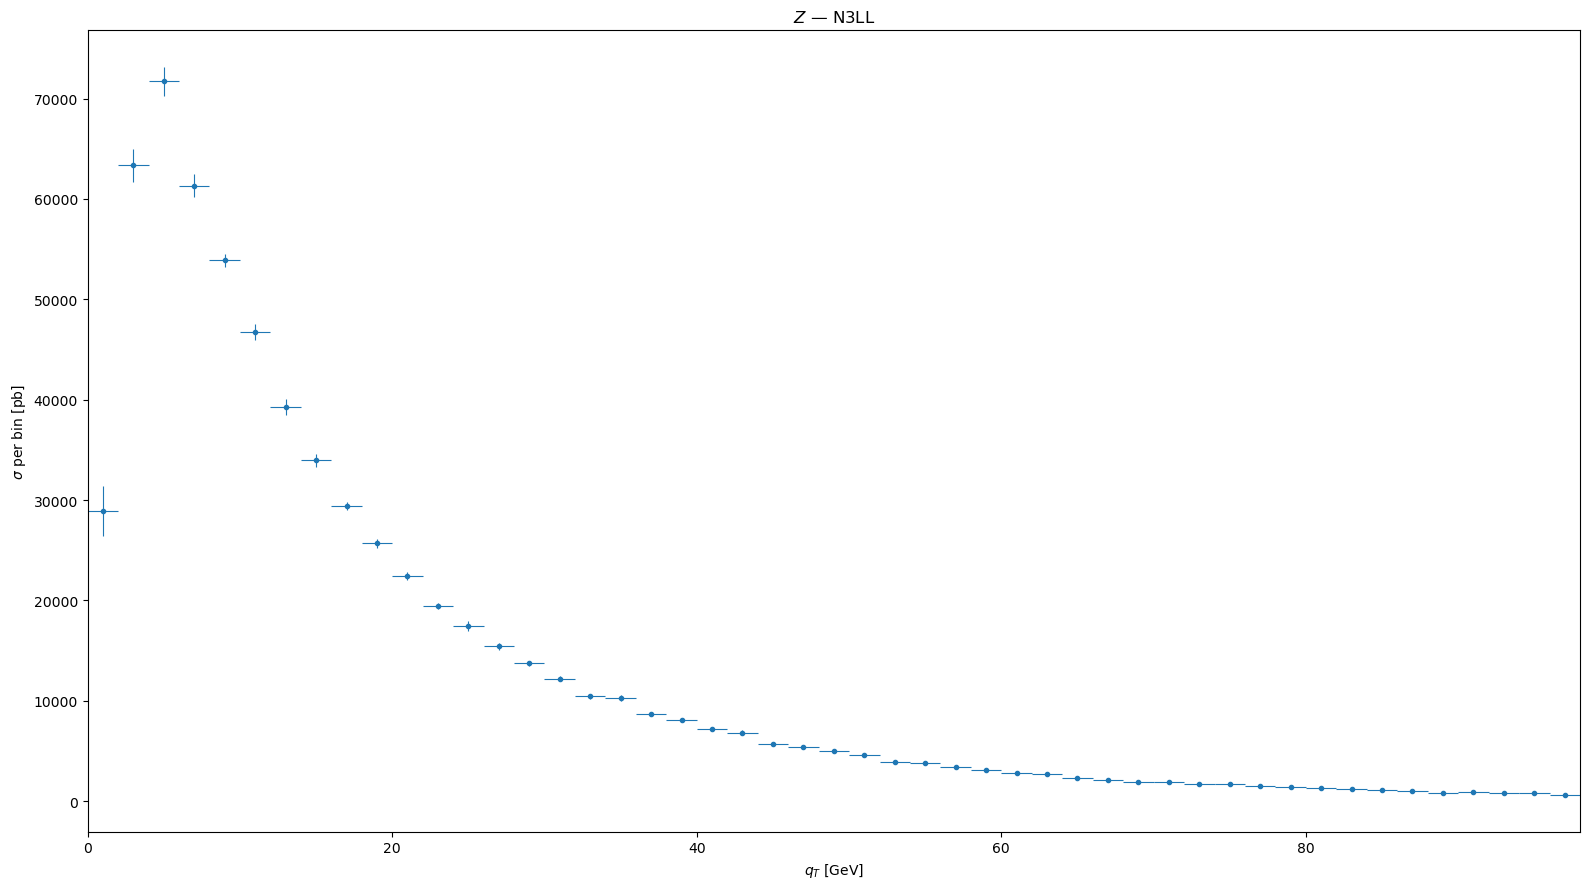

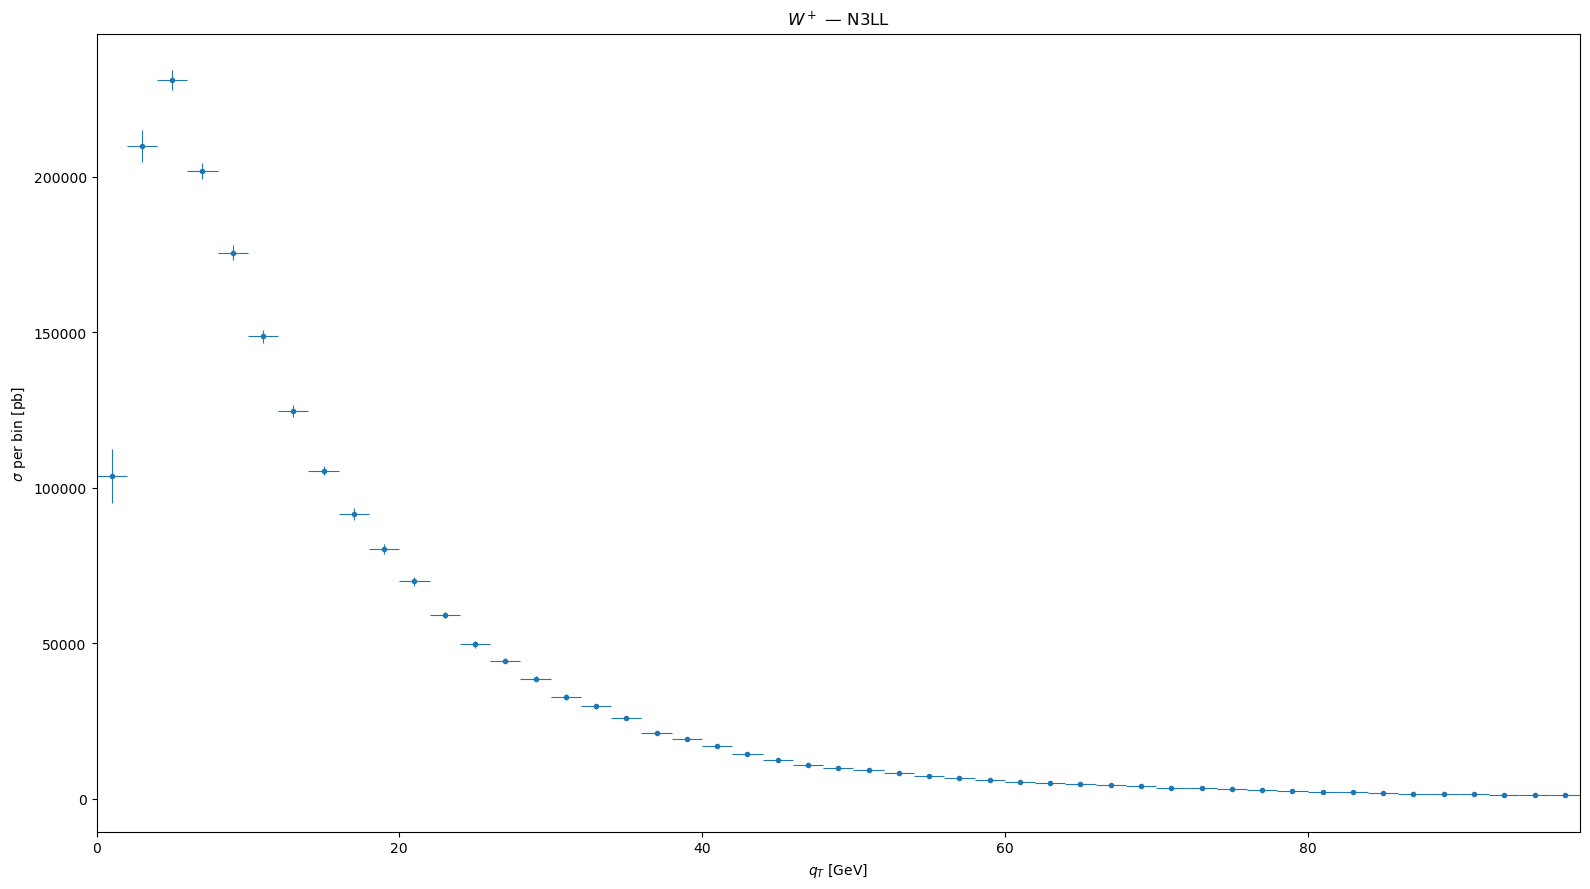

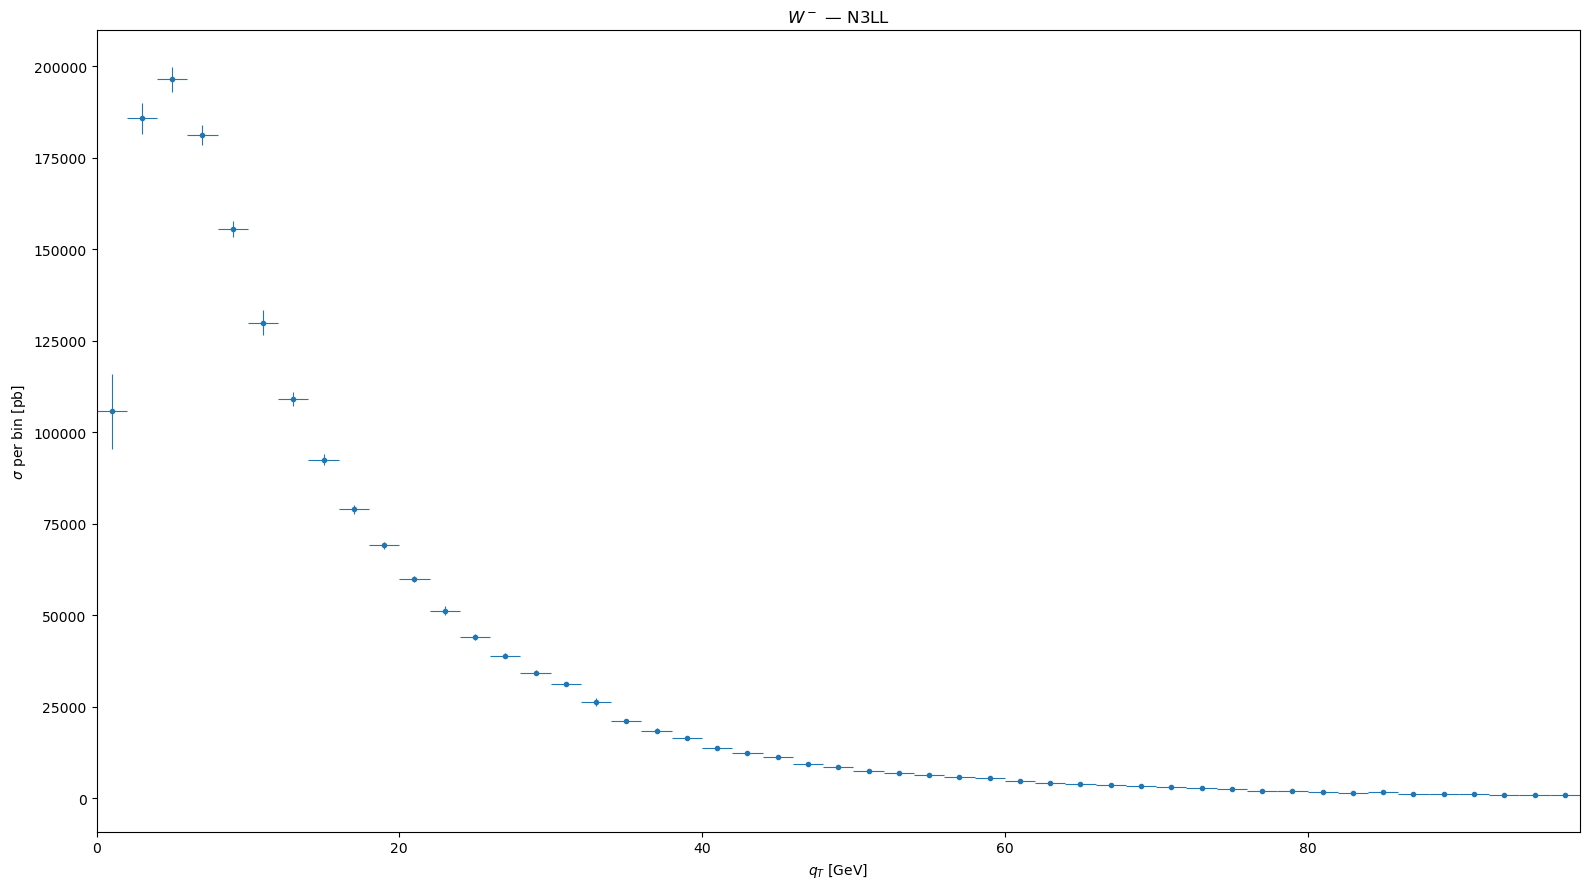

In [124]:
ORDER  = 'N3LL'   # ← 'NLL', 'NNLL', 'N3LL'
titles = {'Z': r'$Z$', 'Wp': r'$W^+$', 'Wm': r'$W^-$'}

nom = nom1d[nom1d['order'] == ORDER].copy()
nom = nom[nom['qt_hi'] < 100]

for boson in ['Z', 'Wp', 'Wm']:
    sub = nom[nom['boson'] == boson]
    w   = (sub['qt_hi'] - sub['qt_lo']).values
    fig, ax = plt.subplots(figsize=(16, 9))
    if ORDER == 'N3LL':
        ax.errorbar(
            sub['qt_center'], sub['value'],
            yerr=sub['error'], xerr=w/2,
            fmt='o', markersize=3, linewidth=0,
            elinewidth=0.8, capsize=0, color='C0'
        )
    else:
        up, lo = envelope(df1d, boson, ORDER)
        ax.bar(sub['qt_lo'].values, (up - lo).values, bottom=lo.values,
               width=w, align='edge', alpha=0.30, color='C0', linewidth=0)
        # ax.step(sub['qt_center'], sub['value'], where='mid', color='C0')
    ax.set_xlabel(r'$q_T$ [GeV]')
    ax.set_ylabel(r'$\sigma$ per bin [pb]')
    ax.set_title(f'{titles[boson]} — {ORDER}')
    ax.set_xlim(0, 98)
    plt.tight_layout()
    plt.show()


## 2 — Distribuzione 1D in q_T: confronto ordini perturbativi

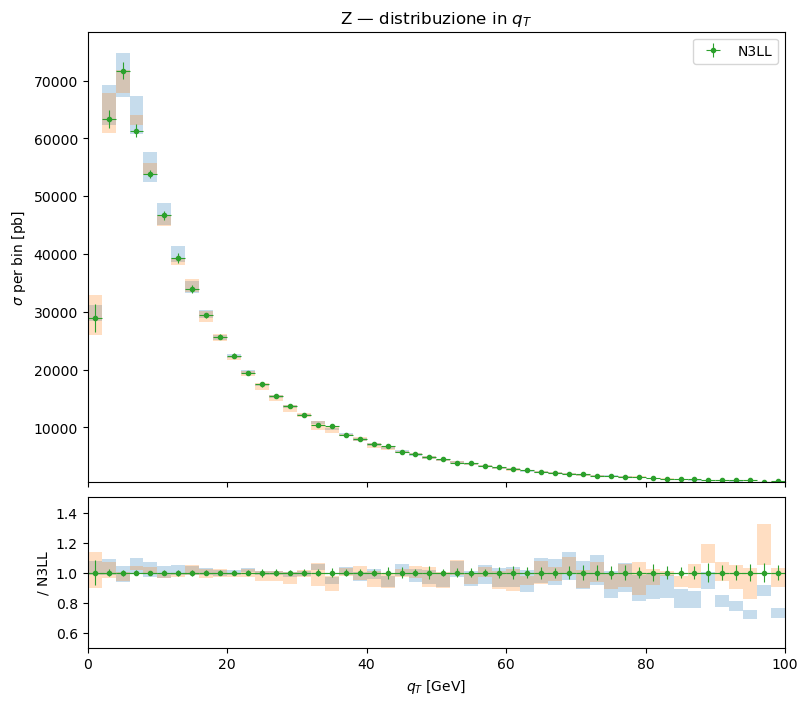

In [125]:
def envelope(df, boson, order, x_col='qt_lo'):
    # Approccio flat: upper=max, lower=min tra tutte le variazioni di scala.
    # Il nominal può cadere fuori dalla banda se le variazioni sono asimmetriche.
    mask = (df.boson == boson) & (df.order == order)
    g = df[mask].groupby(x_col)['value']
    return g.max(), g.min()

# # Approccio centrato sul nominal: la banda è simmetrica attorno al nominal.
# # upper = nominal + max(|var - nominal|)
# # lower = nominal - max(|var - nominal|)
# # Il nominal è sempre al centro della banda per costruzione.
# def envelope(df, boson, order, x_col='qt_lo'):
#     mask = (df.boson == boson) & (df.order == order)
#     nom_mask = mask & (df.muR == 1.0) & (df.muF == 1.0) & (df.muQ == 1.0)
#     nominal = df[nom_mask].groupby(x_col)['value'].first()
#     deviations = df[mask].groupby(x_col)['value'].apply(
#         lambda vals: (vals - nominal[vals.name]).abs().max()
#     )
#     return nominal + deviations, nominal - deviations

BOSON  = 'Z'   # ← 'Z', 'Wp', 'Wm'
colors = {'NLL': 'C0', 'NNLL': 'C1', 'N3LL': 'C2'}

nom  = nom1d[nom1d.boson == BOSON]
ref  = nom[nom.order == 'N3LL'].set_index('qt_lo')['value']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for order, color in colors.items():
    row = nom[nom.order == order]
    qt  = row['qt_center'].values
    val = row['value'].values
    err = row['error'].values
    w   = (row['qt_hi'] - row['qt_lo']).values   # larghezza bin

    if order == 'N3LL':
        # Scatter + barre di errore statistico
        ax1.errorbar(qt, val, yerr=err,
                     xerr=w/2, fmt='o', markersize=3,
                     color=color, linewidth=0,
                     elinewidth=0.8, capsize=0, label=order)
        ratio_n3ll     = val / ref.reindex(row['qt_lo']).values
        ratio_n3ll_err = err / ref.reindex(row['qt_lo']).values
        ax2.errorbar(qt, ratio_n3ll, yerr=ratio_n3ll_err,
                     xerr=w/2, fmt='o', markersize=3,
                     color=color, linewidth=0,
                     elinewidth=0.8, capsize=0)
    else:
        # Nominal come linea
        #ax1.step(qt, val, where='mid', color=color, linewidth=1.4, label=order)

        # Envelope come box colorati (un rettangolo per bin)
        up, lo = envelope(df1d, BOSON, order)
        qt_lo_bins = up.index.values
        ax1.bar(qt_lo_bins, up.values - lo.values, bottom=lo.values,
                width=w, align='edge',
                alpha=0.25, color=color, linewidth=0)

        # Pannello ratio
        ratio    = val / ref.reindex(row['qt_lo']).values
        ratio_up = up.values / ref.values
        ratio_lo = lo.values / ref.values
        #ax2.step(qt, ratio, where='mid', color=color)
        ax2.bar(qt_lo_bins, ratio_up - ratio_lo, bottom=ratio_lo,
                width=w, align='edge',
                alpha=0.25, color=color, linewidth=0)

ax2.axhline(1, color='C2', linewidth=0.8, linestyle='--')
#ax1.set_yscale('log')
ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(); ax1.set_title(f'{BOSON} — distribuzione in $q_T$')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('/ N3LL')
ax2.set_xlim(0, 100); ax2.set_ylim(0.5, 1.5)
plt.show()

## 3 — Griglia 2D: heatmap (q_T, p_T^l)

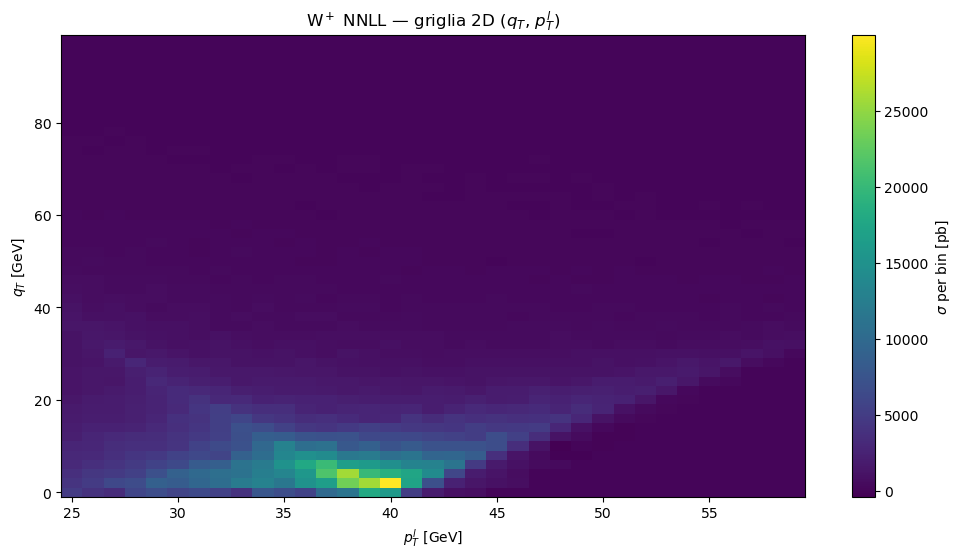

In [126]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'

sel  = df2d_wp.query("order == @ORDER and muF==1.0 and muQ==1.0 and muR==1.0")
grid = sel.pivot_table(index='qt_lo', columns='ptl_lo', values='value')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\sigma$ per bin [pb]')
ax.set_xlabel(r'$p_T^l$ [GeV]'); ax.set_ylabel(r'$q_T$ [GeV]')
ax.set_title(f'W$^+$ {ORDER} — griglia 2D ($q_T$, $p_T^l$)')
plt.show()

## 6 — Lookup: valore per una coppia di bin specifica

In [130]:
# ── modifica questi parametri ──────────────────────────────
QT_LO  = 20
PTL_LO = 35
ORDER  = 'NNLL'
BOSON  = 'Wp'   # 'Wp' o 'Wm'
MUR, MUF, MUQ = 1.0, 1.0, 1.0
# ───────────────────────────────────────────────────────────

df2d = df2d_wp if BOSON == 'Wp' else df2d_wm
row  = df2d.query(
    "order==@ORDER and muR==@MUR and muF==@MUF and muQ==@MUQ "
    "and qt_lo==@QT_LO and ptl_lo==@PTL_LO"
)

if row.empty:
    print(f'Nessun bin trovato per qt_lo={QT_LO}, ptl_lo={PTL_LO}')
    print(f'qt  disponibili: {sorted(df2d.qt_lo.unique().tolist())}')
    print(f'ptl disponibili: {sorted(df2d.ptl_lo.unique().tolist())}')
else:
    r = row.iloc[0]
    print(f'Boson: {BOSON}  |  Ordine: {ORDER}  |  muR={MUR}  muF={MUF}  muQ={MUQ}')
    print(f'qt  ∈ [{r.qt_lo:.0f}, {r.qt_hi:.0f}] GeV')
    print(f'ptl ∈ [{r.ptl_lo:.0f}, {r.ptl_hi:.0f}] GeV')
    print(f'valore : {r.value:.6g} pb')
    print(f'errore : {r.error:.6g} pb  ({100*r.error/abs(r.value):.2f}%)')

Boson: Wp  |  Ordine: NNLL  |  muR=1.0  muF=1.0  muQ=1.0
qt  ∈ [20, 22] GeV
ptl ∈ [35, 36] GeV
valore : 2553.05 pb
errore : 151.29 pb  (5.93%)


## 7 — Confronto: proiezione 2D→q_T vs distribuzione 1D

La proiezione in q_T è precalcolata in `2D.root` come `proj_qt`.  
Il confronto con il 1D mostra la frazione di sezione d'urto coperta dalla regione fiduciale p_T^l ∈ [25,60] GeV.

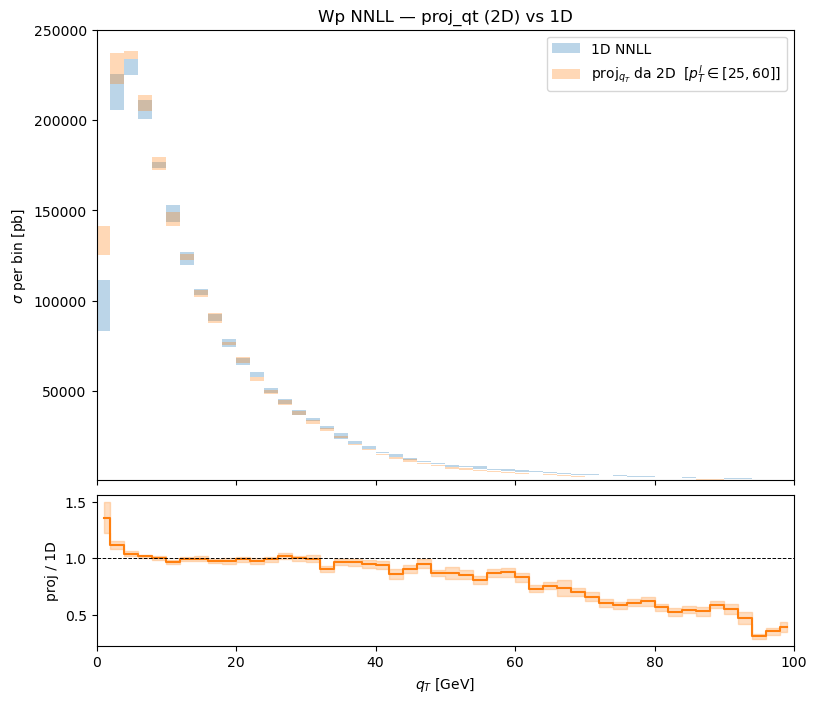

In [131]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'

nom = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"

w1d  = df1d.query(f"boson=='{BOSON}' and {nom}").set_index('qt_lo').sort_index()
wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom}").set_index('qt_lo').sort_index()

common = sorted(set(w1d.index) & set(wpqt.index))
qt_c   = w1d.loc[common, 'qt_center'].values
w_arr  = (w1d.loc[common, 'qt_hi'] - np.array(common)).values
v1d,  e1d  = w1d.loc[common,  'value'].values, w1d.loc[common,  'error'].values
vpqt, epqt = wpqt.loc[common, 'value'].values, wpqt.loc[common, 'error'].values

up_1d,  lo_1d  = envelope(df1d,   BOSON, ORDER, x_col='qt_lo')
up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(qt_c, v1d,  yerr=e1d,  xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0, label=f'1D {ORDER}')
    ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{q_T}$ da 2D  [$p_T^l\in[25,60]$]')
else:
    ax1.bar(np.array(common), (up_1d.reindex(common)-lo_1d.reindex(common)).values,
            bottom=lo_1d.reindex(common).values, width=w_arr, align='edge',
            alpha=0.30, color='C0', linewidth=0, label=f'1D {ORDER}')
    # ax1.step(qt_c, v1d, where='mid', color='C0')
    ax1.bar(np.array(common), (up_pqt.reindex(common)-lo_pqt.reindex(common)).values,
            bottom=lo_pqt.reindex(common).values, width=w_arr, align='edge',
            alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{q_T}$ da 2D  [$p_T^l\in[25,60]$]')
    # ax1.step(qt_c, vpqt, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj_qt (2D) vs 1D')

ratio     = vpqt / v1d
ratio_err = ratio * np.sqrt((epqt/vpqt)**2 + (e1d/v1d)**2)
if ORDER == 'N3LL':
    ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ax2.step(qt_c, ratio, where='mid', color='C1')
    ax2.fill_between(qt_c, ratio-ratio_err, ratio+ratio_err, step='mid', alpha=0.25, color='C1')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('proj / 1D')
ax2.set_xlim(0, 100)
plt.show()


## 8 — Distribuzione in p_T^l: proiezione 2D e confronto ordini

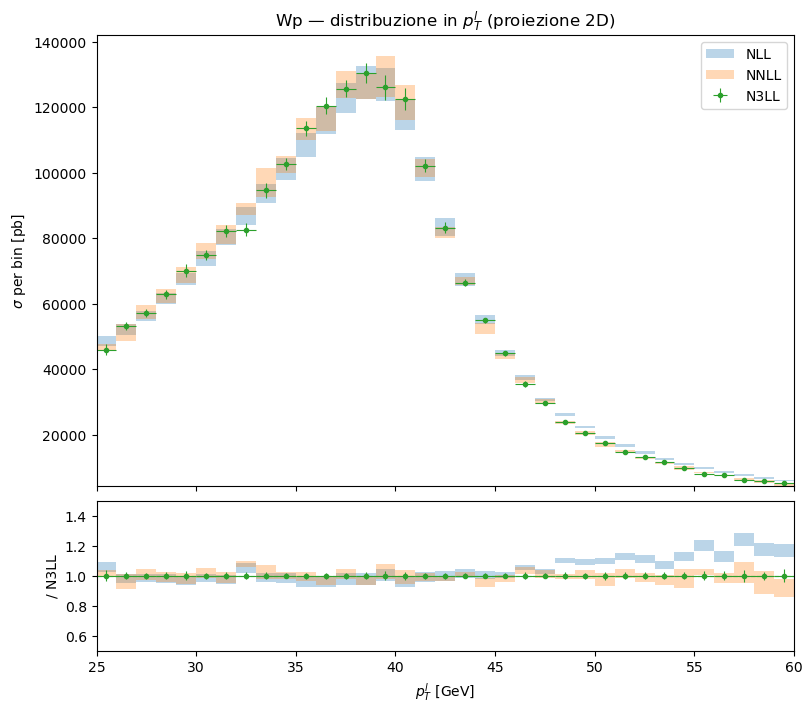

In [132]:
# Confronto NLL / NNLL / N3LL per la proiezione in p_T^l
BOSON  = 'Wp'   # ← 'Wp' o 'Wm'
colors = {'NLL': 'C0', 'NNLL': 'C1', 'N3LL': 'C2'}

nom_ptl = df_pptl.query("muF==1.0 and muQ==1.0 and muR==1.0")
ref_ptl = nom_ptl.query(f"boson=='{BOSON}' and order=='N3LL'").set_index('ptl_lo')['value']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for order, color in colors.items():
    row = nom_ptl.query(f"boson=='{BOSON}' and order=='{order}'")
    ptl = row['ptl_center'].values
    val = row['value'].values
    err = row['error'].values
    w   = (row['ptl_hi'] - row['ptl_lo']).values

    if order == 'N3LL':
        ax1.errorbar(ptl, val, yerr=err, xerr=w/2,
                     fmt='o', markersize=3, color=color, linewidth=0,
                     elinewidth=0.8, capsize=0, label=order)
        ratio_n3ll     = val / ref_ptl.reindex(row['ptl_lo']).values
        ratio_n3ll_err = err / ref_ptl.reindex(row['ptl_lo']).values
        ax2.errorbar(ptl, ratio_n3ll, yerr=ratio_n3ll_err, xerr=w/2,
                     fmt='o', markersize=3, color=color, linewidth=0,
                     elinewidth=0.8, capsize=0)
    else:
        up, lo = envelope(df_pptl, BOSON, order, x_col='ptl_lo')
        # ax1.step(ptl, val, where='mid', color=color, linewidth=1.2)
        ax1.bar(row['ptl_lo'].values, (up - lo).values, bottom=lo.values,
                width=w, align='edge', alpha=0.30, color=color, linewidth=0, label=order)
        ratio    = val / ref_ptl.reindex(row['ptl_lo']).values
        ratio_up = up.values / ref_ptl.values
        ratio_lo = lo.values / ref_ptl.values
        ax2.bar(row['ptl_lo'].values, ratio_up - ratio_lo, bottom=ratio_lo,
                width=w, align='edge', alpha=0.30, color=color, linewidth=0)

ax2.axhline(1, color='C2', linewidth=0.8, linestyle='--')
ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(); ax1.set_title(f'{BOSON} — distribuzione in $p_T^l$ (proiezione 2D)')
ax2.set_xlabel(r'$p_T^l$ [GeV]'); ax2.set_ylabel('/ N3LL')
ax2.set_xlim(25, 60); ax2.set_ylim(0.5, 1.5)
plt.show()


## 9 — Confronto: proj_ptl vs somma diretta 2D su q_T

Per ogni bin in $p_T^l$ si sommano tutti i bin in $q_T$ della griglia 2D (errori in quadratura).  
Il risultato deve coincidere con la proiezione precalcolata `proj_ptl`.

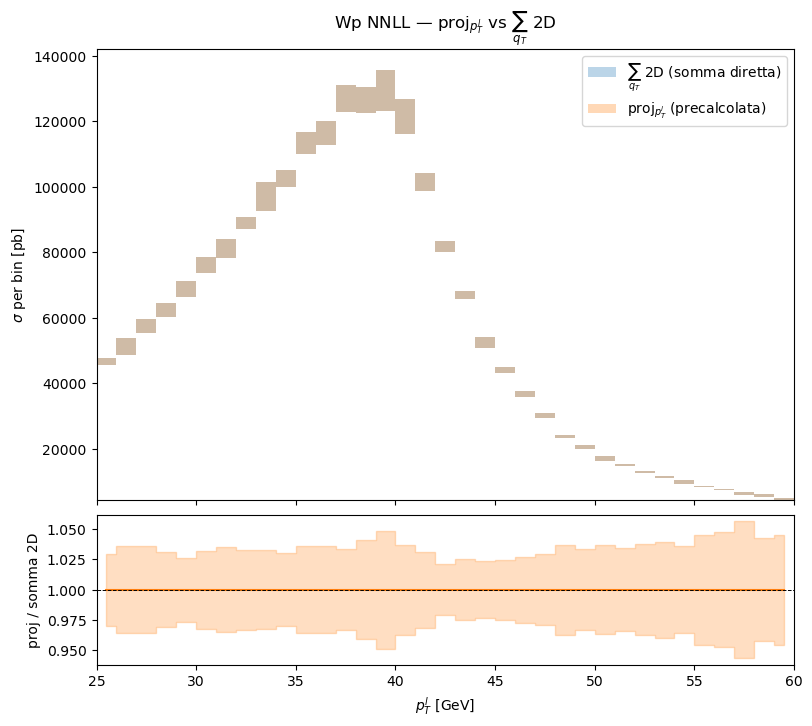

In [134]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'     # ← 'Wp', 'Wm'

nom_q = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"
df2d  = df2d_wp if BOSON == 'Wp' else df2d_wm

nom2d   = df2d.query(nom_q)
sum_ptl = (nom2d.groupby('ptl_lo')
                .agg(value=('value', 'sum'),
                     error=('error', lambda x: np.sqrt((x**2).sum())))
                .sort_index())

wpptl = df_pptl.query(f"boson=='{BOSON}' and {nom_q}").set_index('ptl_lo').sort_index()

common  = sorted(set(sum_ptl.index) & set(wpptl.index))
ptl_c   = wpptl.loc[common, 'ptl_center'].values
w_arr   = (wpptl.loc[common, 'ptl_hi'] - np.array(common)).values
v2d,  e2d    = sum_ptl.loc[common, 'value'].values,  sum_ptl.loc[common, 'error'].values
vpptl, epptl = wpptl.loc[common, 'value'].values,    wpptl.loc[common, 'error'].values

g_env_2d = (df2d[df2d.order == ORDER]
             .groupby(['muR','muF','muQ','ptl_lo'])['value'].sum()
             .reset_index().groupby('ptl_lo')['value'])
up_2d     = g_env_2d.max().reindex(common).values
lo_2d     = g_env_2d.min().reindex(common).values

up_pptl, lo_pptl = envelope(df_pptl, BOSON, ORDER, x_col='ptl_lo')
up_pptl_c = up_pptl.reindex(common).values
lo_pptl_c = lo_pptl.reindex(common).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(ptl_c, v2d,   yerr=e2d,   xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'$\sum_{q_T}$ 2D (somma diretta)')
    ax1.errorbar(ptl_c, vpptl, yerr=epptl, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{p_T^l}$ (precalcolata)')
else:
    ax1.bar(np.array(common), up_2d - lo_2d, bottom=lo_2d,
            width=w_arr, align='edge', alpha=0.30, color='C0', linewidth=0,
            label=r'$\sum_{q_T}$ 2D (somma diretta)')
    # ax1.step(ptl_c, v2d, where='mid', color='C0')
    ax1.bar(np.array(common), up_pptl_c - lo_pptl_c, bottom=lo_pptl_c,
            width=w_arr, align='edge', alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{p_T^l}$ (precalcolata)')
    # ax1.step(ptl_c, vpptl, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj$_{{p_T^l}}$ vs $\sum_{{q_T}}$ 2D')

ratio     = vpptl / v2d
ratio_err = ratio * np.sqrt((epptl/vpptl)**2 + (e2d/v2d)**2)
if ORDER == 'N3LL':
    ax2.errorbar(ptl_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ax2.step(ptl_c, ratio, where='mid', color='C1')
    ax2.fill_between(ptl_c, ratio-ratio_err, ratio+ratio_err, step='mid', alpha=0.25, color='C1')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$p_T^l$ [GeV]'); ax2.set_ylabel('proj / somma 2D')
ax2.set_xlim(25, 60)
plt.show()


## 10 — Confronto: proj_qT vs somma diretta 2D su p_T^l

Per ogni bin in $q_T$ si sommano tutti i bin in $p_T^l$ della griglia 2D (errori in quadratura).  
Il risultato deve coincidere con la proiezione precalcolata `proj_qt`.

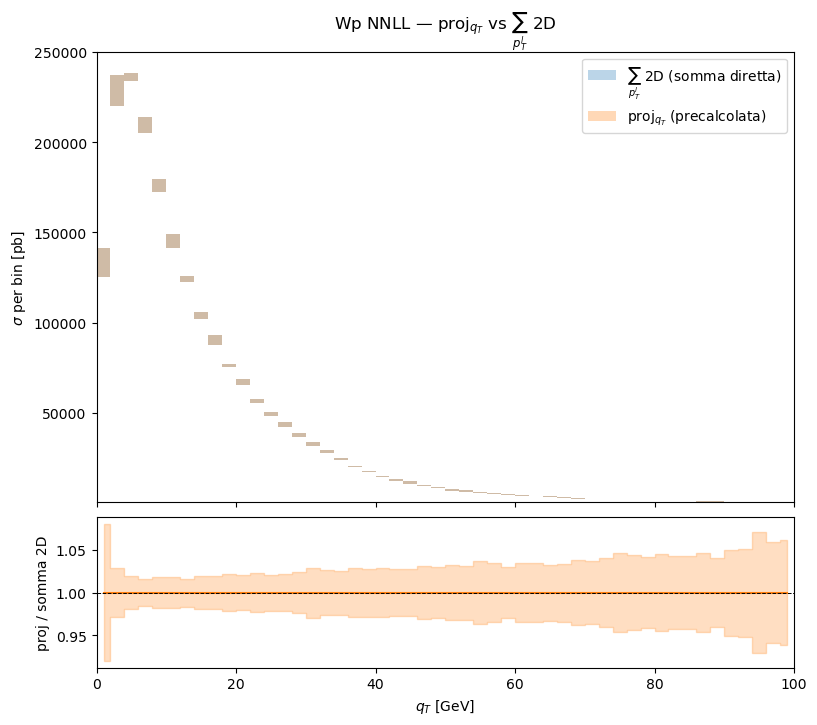

In [135]:
ORDER = 'NNLL'   # ← 'NLL', 'NNLL', 'N3LL'
BOSON = 'Wp'     # ← 'Wp', 'Wm'

nom_q = f"order=='{ORDER}' and muF==1.0 and muQ==1.0 and muR==1.0"
df2d  = df2d_wp if BOSON == 'Wp' else df2d_wm

nom2d  = df2d.query(nom_q)
sum_qt = (nom2d.groupby('qt_lo')
               .agg(value=('value', 'sum'),
                    error=('error', lambda x: np.sqrt((x**2).sum())))
               .sort_index())

wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()

common = sorted(set(sum_qt.index) & set(wpqt.index))
qt_c   = wpqt.loc[common, 'qt_center'].values
w_arr  = (wpqt.loc[common, 'qt_hi'] - np.array(common)).values
v2d,  e2d   = sum_qt.loc[common, 'value'].values, sum_qt.loc[common, 'error'].values
vpqt, epqt  = wpqt.loc[common, 'value'].values,   wpqt.loc[common, 'error'].values

g_env_2d = (df2d[df2d.order == ORDER]
             .groupby(['muR','muF','muQ','qt_lo'])['value'].sum()
             .reset_index().groupby('qt_lo')['value'])
up_2d     = g_env_2d.max().reindex(common).values
lo_2d     = g_env_2d.min().reindex(common).values

up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')
up_pqt_c = up_pqt.reindex(common).values
lo_pqt_c = lo_pqt.reindex(common).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

if ORDER == 'N3LL':
    ax1.errorbar(qt_c, v2d,  yerr=e2d,  xerr=w_arr/2, fmt='o', markersize=3,
                 color='C0', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'$\sum_{p_T^l}$ 2D (somma diretta)')
    ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0,
                 label=r'proj$_{q_T}$ (precalcolata)')
else:
    ax1.bar(np.array(common), up_2d - lo_2d, bottom=lo_2d,
            width=w_arr, align='edge', alpha=0.30, color='C0', linewidth=0,
            label=r'$\sum_{p_T^l}$ 2D (somma diretta)')
    # ax1.step(qt_c, v2d, where='mid', color='C0')
    ax1.bar(np.array(common), up_pqt_c - lo_pqt_c, bottom=lo_pqt_c,
            width=w_arr, align='edge', alpha=0.30, color='C1', linewidth=0,
            label=r'proj$_{q_T}$ (precalcolata)')
    # ax1.step(qt_c, vpqt, where='mid', color='C1', linestyle='--')

ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(); ax1.set_title(f'{BOSON} {ORDER} — proj$_{{q_T}}$ vs $\sum_{{p_T^l}}$ 2D')

ratio     = vpqt / v2d
ratio_err = ratio * np.sqrt((epqt/vpqt)**2 + (e2d/v2d)**2)
if ORDER == 'N3LL':
    ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2, fmt='s', markersize=3,
                 color='C1', linewidth=0, elinewidth=0.8, capsize=0)
else:
    ax2.step(qt_c, ratio, where='mid', color='C1')
    ax2.fill_between(qt_c, ratio-ratio_err, ratio+ratio_err, step='mid', alpha=0.25, color='C1')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel('proj / somma 2D')
ax2.set_xlim(0, 100)
plt.show()


## 11 — Confronto globale: 1D vs proj_qT  (NNLL & N3LL)

- **C0** (blu): distribuzione 1D inclusiva in $q_T$
- **C1** (arancio): proj$_{q_T}$ — solo $p_T^l \in [25,60]$ GeV
- **barre**: NNLL — envelope di scala (min/max variazioni)
- **scatter**: N3LL — pseudo-dati con errore Monte Carlo

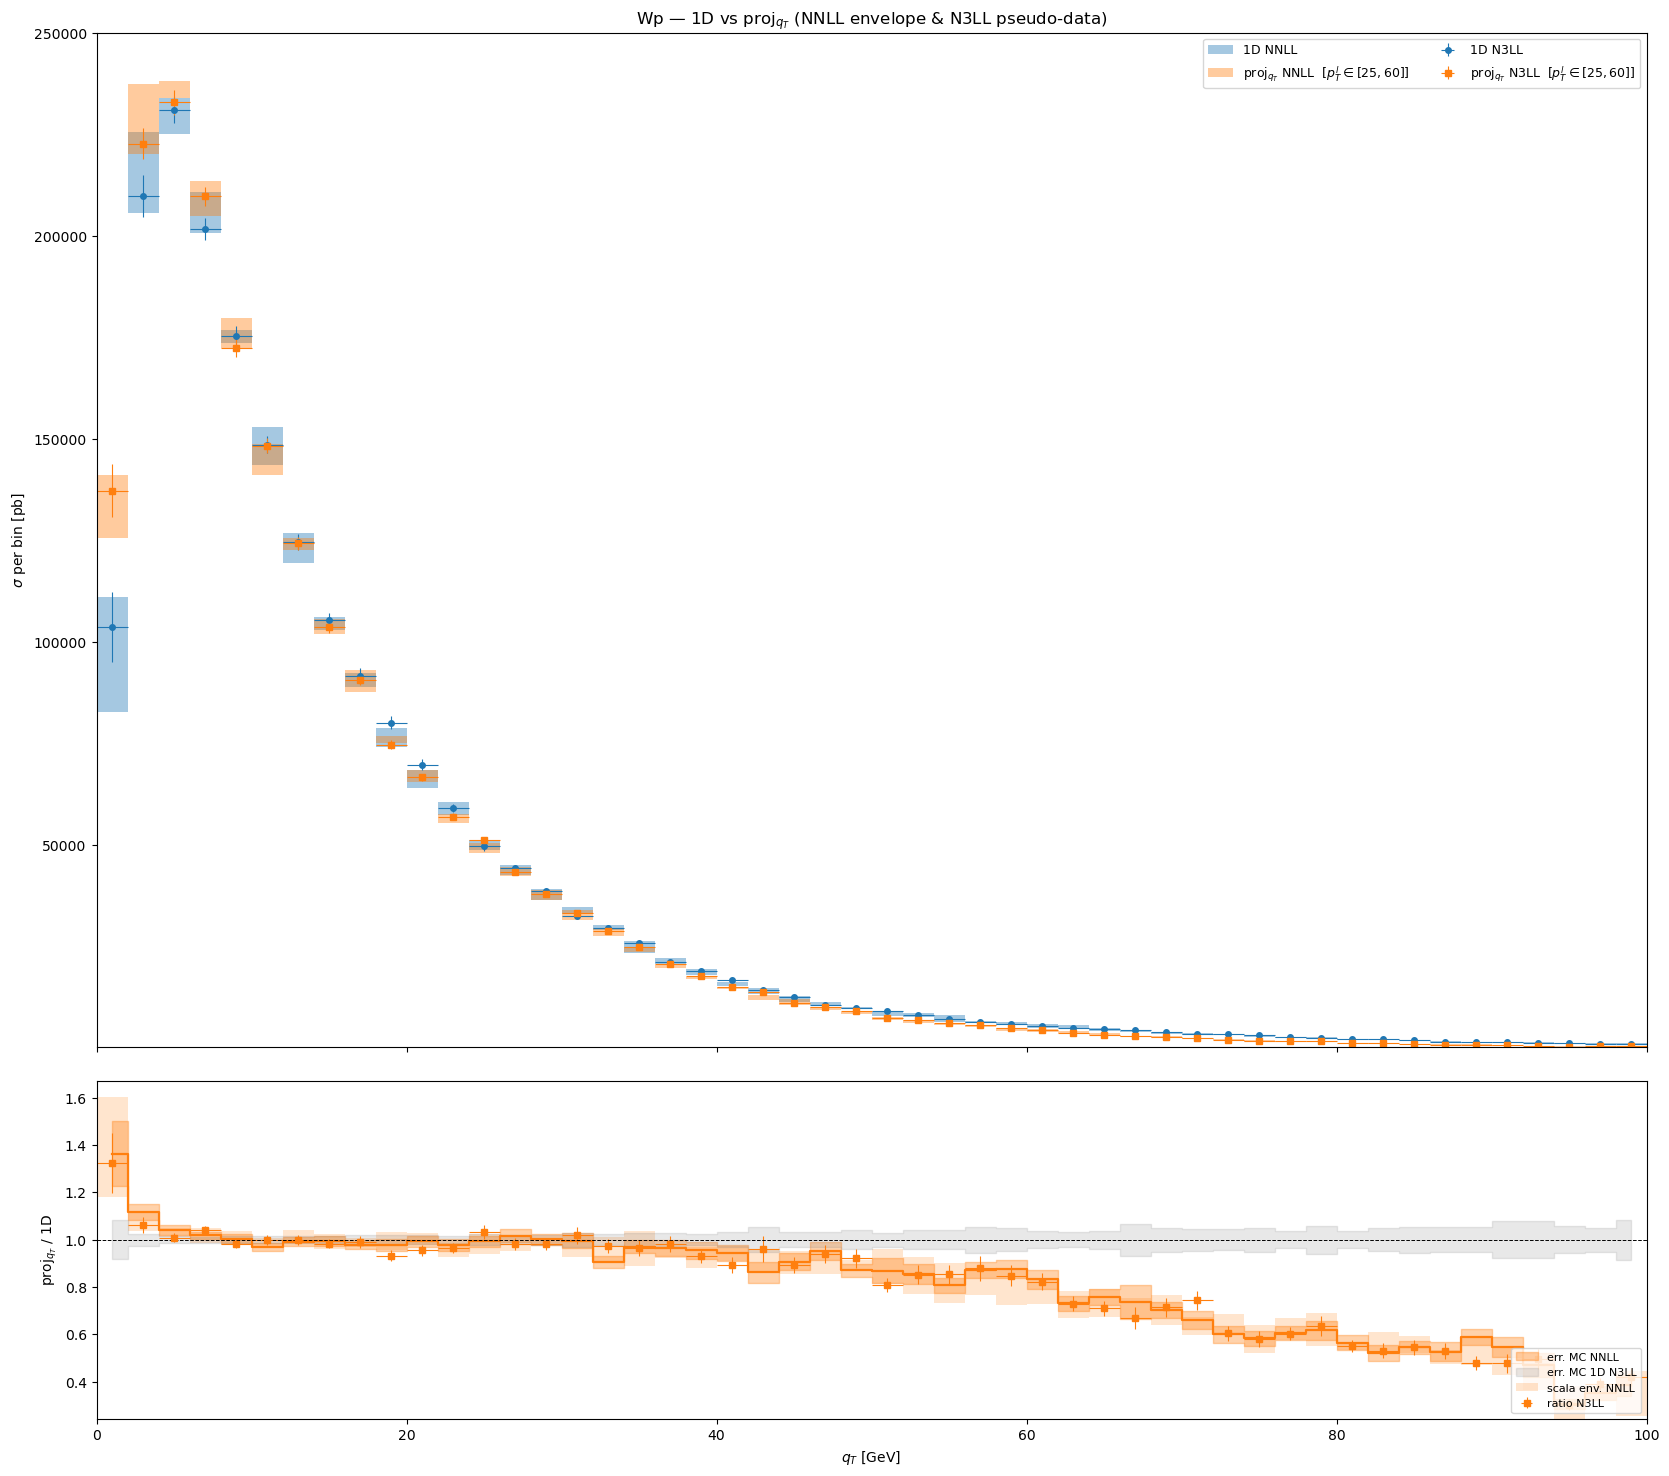

In [151]:
BOSON    = 'Wp'   # ← 'Wp', 'Wm'
nom_base = "muF==1.0 and muQ==1.0 and muR==1.0"

# C0 = 1D  |  C1 = proj_qT  |  bar = NNLL envelope  |  scatter = N3LL pseudo-data
COL_1D   = 'C0'
COL_PROJ = 'C1'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 18), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

for ORDER in ['NNLL', 'N3LL']:
    nom_q = f"order=='{ORDER}' and {nom_base}"

    w1d  = df1d.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()
    wpqt = df_pqt.query(f"boson=='{BOSON}' and {nom_q}").set_index('qt_lo').sort_index()

    common = sorted(set(w1d.index) & set(wpqt.index))
    qt_c   = w1d.loc[common, 'qt_center'].values
    w_arr  = (w1d.loc[common, 'qt_hi'] - np.array(common)).values
    v1d,   e1d  = w1d.loc[common,  'value'].values, w1d.loc[common,  'error'].values
    vpqt,  epqt = wpqt.loc[common, 'value'].values, wpqt.loc[common, 'error'].values

    up_1d,  lo_1d  = envelope(df1d,   BOSON, ORDER, x_col='qt_lo')
    up_pqt, lo_pqt = envelope(df_pqt, BOSON, ORDER, x_col='qt_lo')

    ratio     = vpqt / v1d
    ratio_err = ratio * np.sqrt((epqt/vpqt)**2 + (e1d/v1d)**2)

    if ORDER == 'N3LL':
        # ── pannello superiore ─────────────────────────────────────────────
        ax1.errorbar(qt_c, v1d,  yerr=e1d,  xerr=w_arr/2,
                     fmt='o', markersize=4, color=COL_1D, linewidth=0,
                     elinewidth=0.8, capsize=0, label=f'1D {ORDER}')
        ax1.errorbar(qt_c, vpqt, yerr=epqt, xerr=w_arr/2,
                     fmt='s', markersize=4, color=COL_PROJ, linewidth=0,
                     elinewidth=0.8, capsize=0,
                     label=rf'proj$_{{q_T}}$ {ORDER}  [$p_T^l\in[25,60]$]')
        # ── ratio panel ────────────────────────────────────────────────────
        # banda grigia: incertezza MC della misura 1D (denominatore del ratio)
        e1d_rel = e1d / v1d
        ax2.fill_between(qt_c, 1 - e1d_rel, 1 + e1d_rel,
                         step='mid', alpha=0.18, color='gray',
                         label='err. MC 1D N3LL')
        # scatter ratio con errore totale propagato (proj + 1D)
        ax2.errorbar(qt_c, ratio, yerr=ratio_err, xerr=w_arr/2,
                     fmt='s', markersize=4, color=COL_PROJ, linewidth=0,
                     elinewidth=0.8, capsize=0, label='ratio N3LL')

    else:  # NNLL ─────────────────────────────────────────────────────────
        # ── pannello superiore ─────────────────────────────────────────────
        ax1.bar(np.array(common),
                (up_1d.reindex(common) - lo_1d.reindex(common)).values,
                bottom=lo_1d.reindex(common).values,
                width=w_arr, align='edge', alpha=0.40, color=COL_1D,
                linewidth=0, label=f'1D {ORDER}')
        # ax1.step(qt_c, v1d, where='mid', color=COL_1D)  # nominale
        ax1.bar(np.array(common),
                (up_pqt.reindex(common) - lo_pqt.reindex(common)).values,
                bottom=lo_pqt.reindex(common).values,
                width=w_arr, align='edge', alpha=0.40, color=COL_PROJ,
                linewidth=0, label=rf'proj$_{{q_T}}$ {ORDER}  [$p_T^l\in[25,60]$]')
        # ax1.step(qt_c, vpqt, where='mid', color=COL_PROJ, linestyle='--')  # nominale

        # ── envelope del ratio: ratio(μ) = proj(μ)/1D(μ) per ogni variazione di scala
        proj_sc = (df_pqt[(df_pqt.boson == BOSON) & (df_pqt.order == ORDER)]
                   [['muR','muF','muQ','qt_lo','value']]
                   .rename(columns={'value': 'vp'}))
        id1d_sc = (df1d[(df1d.boson == BOSON) & (df1d.order == ORDER)]
                   [['muR','muF','muQ','qt_lo','value']]
                   .rename(columns={'value': 'v1'}))
        merged = proj_sc.merge(id1d_sc, on=['muR','muF','muQ','qt_lo'])
        merged['r'] = merged['vp'] / merged['v1']
        g_ratio = merged[merged['qt_lo'].isin(common)].groupby('qt_lo')['r']
        up_re = g_ratio.max().reindex(common).values
        lo_re = g_ratio.min().reindex(common).values

        # ── ratio panel ────────────────────────────────────────────────────
        # envelope di scala (barra più larga, più trasparente)
        ax2.bar(np.array(common), up_re - lo_re, bottom=lo_re,
                width=w_arr, align='edge', alpha=0.20, color=COL_PROJ,
                linewidth=0, label='scala env. NNLL')
        # nominale + errore MC stat (più stretto, più opaco)
        ax2.step(qt_c, ratio, where='mid', color=COL_PROJ, linewidth=1.6)
        ax2.fill_between(qt_c, ratio - ratio_err, ratio + ratio_err,
                         step='mid', alpha=0.35, color=COL_PROJ,
                         label='err. MC NNLL')

ax1.set_ylabel(r'$\sigma$ per bin [pb]')
ax1.legend(ncols=2, fontsize=9)
ax1.set_title(f'{BOSON} — 1D vs proj$_{{q_T}}$ (NNLL envelope & N3LL pseudo-data)')
ax2.axhline(1, color='k', linewidth=0.7, linestyle='--')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlabel(r'$q_T$ [GeV]'); ax2.set_ylabel(r'proj$_{{q_T}}$ / 1D')
ax2.set_xlim(0, 100)
plt.show()


## 13 — Z: ratio (ordine, variazione di scala) / N3LL  —  plot individuali

Un plot separato per ogni combinazione $(\mu_R, \mu_F, \mu_Q)$ accettabile, per NLL e NNLL.  
Banda colorata = errore MC propagato; banda grigia = errore relativo N3LL.

NLL  muR=0.5  muF=0.5  muQ=0.5 | ratio[0]=1.0198  ratio[-1]=0.7293  nrows=50


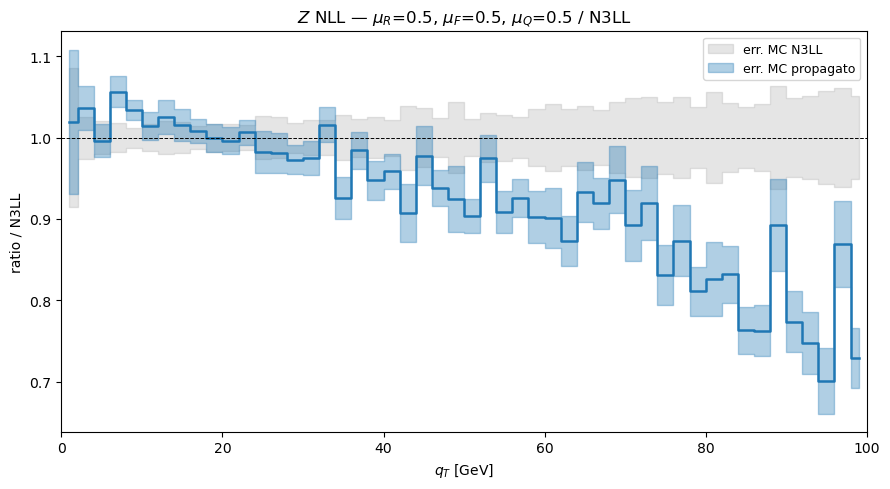

NLL  muR=0.5  muF=0.5  muQ=1.0 | ratio[0]=1.0191  ratio[-1]=0.7289  nrows=50


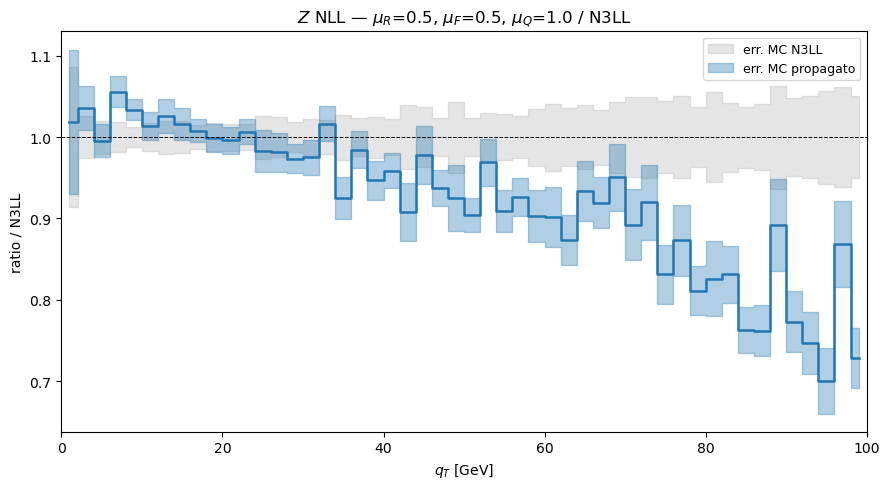

NLL  muR=0.5  muF=1.0  muQ=0.5 | ratio[0]=1.0800  ratio[-1]=0.7612  nrows=50


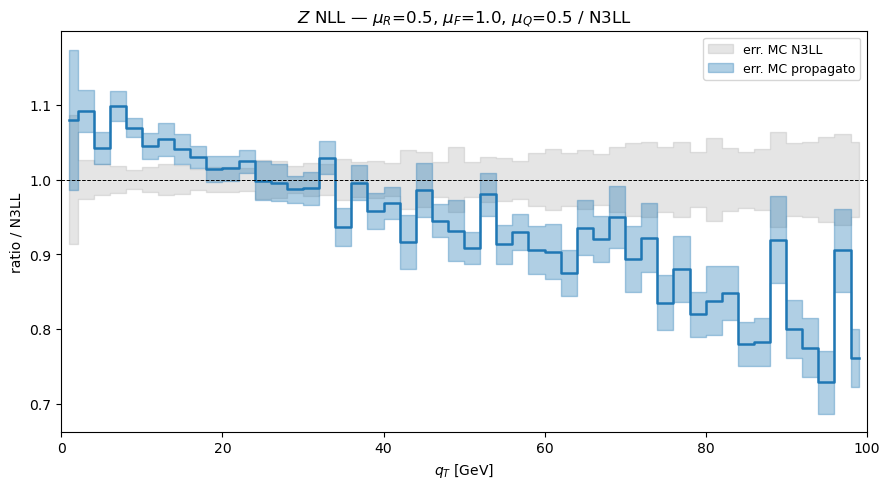

NLL  muR=0.5  muF=1.0  muQ=1.0 | ratio[0]=1.0790  ratio[-1]=0.7607  nrows=50


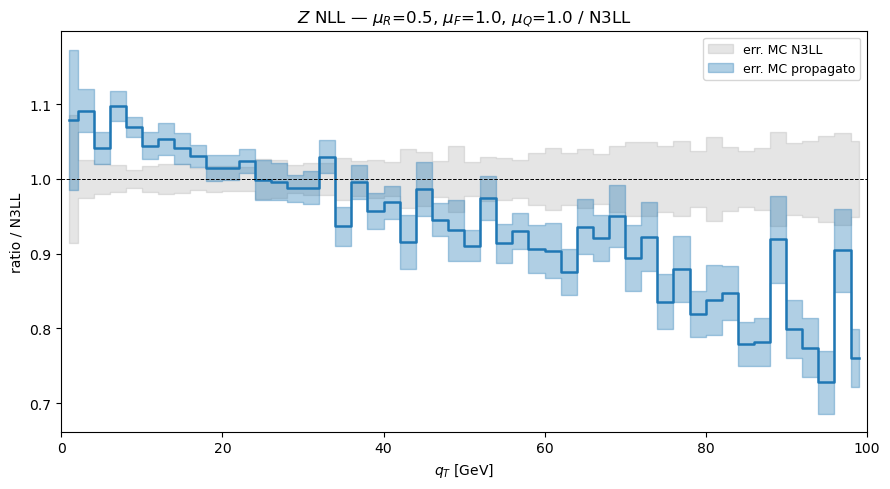

NLL  muR=1.0  muF=0.5  muQ=0.5 | ratio[0]=0.9827  ratio[-1]=0.6981  nrows=50


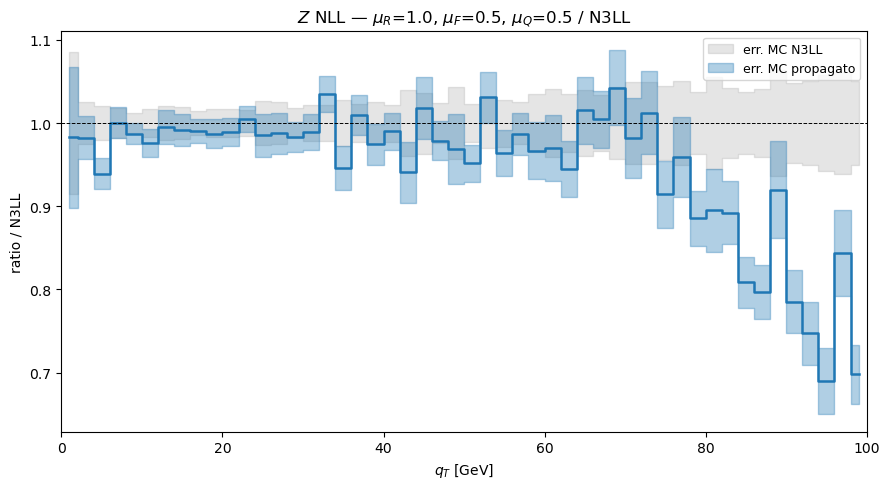

NLL  muR=1.0  muF=0.5  muQ=1.0 | ratio[0]=0.9828  ratio[-1]=0.6983  nrows=50


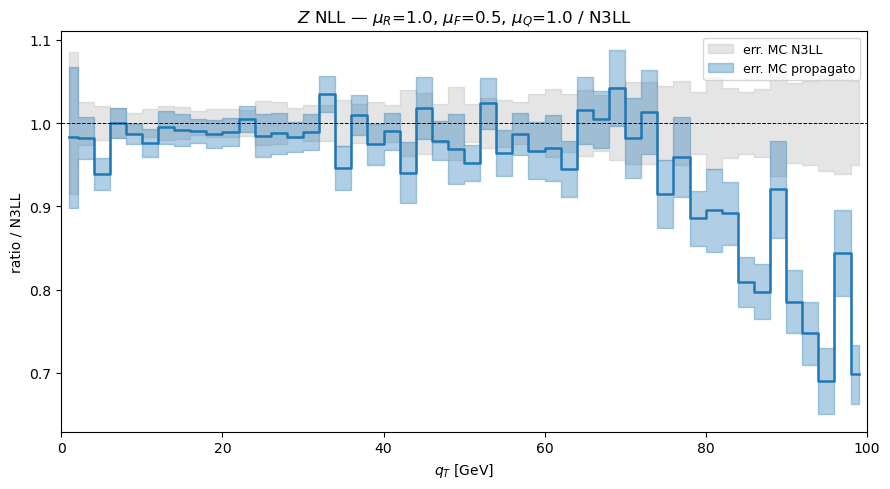

NLL  muR=1.0  muF=1.0  muQ=0.5 | ratio[0]=1.0090  ratio[-1]=0.7298  nrows=50


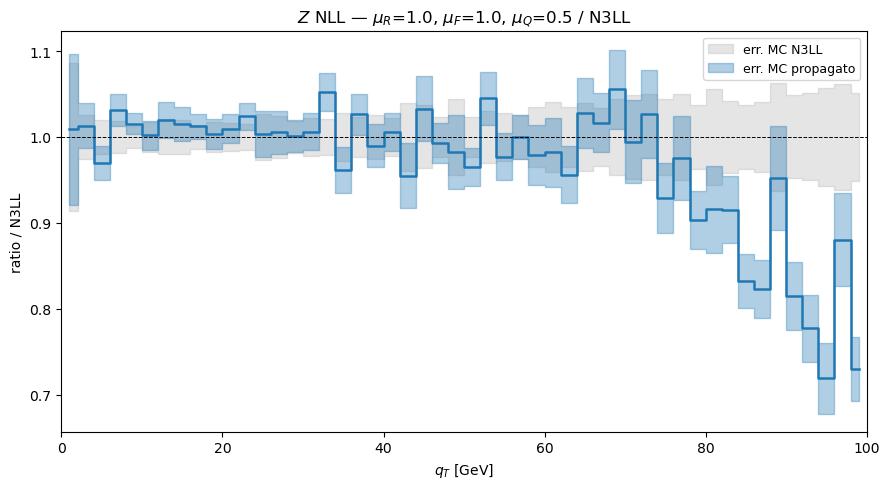

NLL  muR=1.0  muF=1.0  muQ=1.0 | ratio[0]=1.0089  ratio[-1]=0.7299  nrows=50


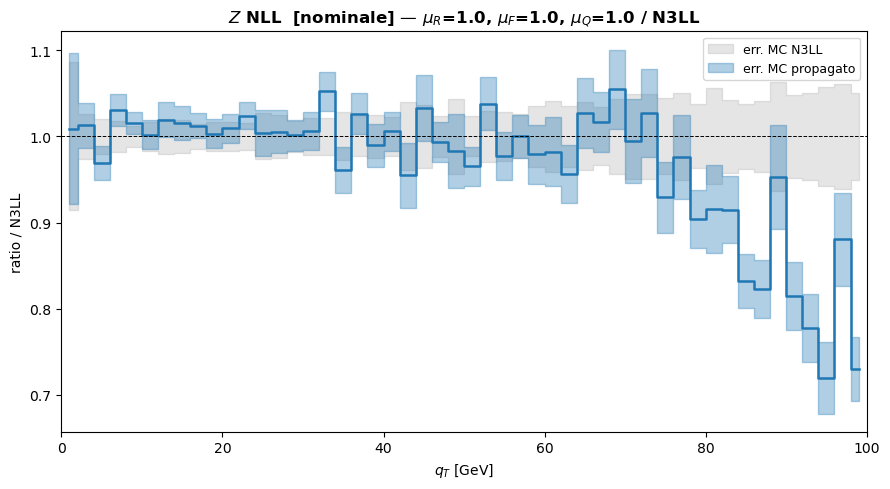

NLL  muR=1.0  muF=1.0  muQ=2.0 | ratio[0]=1.0089  ratio[-1]=0.7299  nrows=50


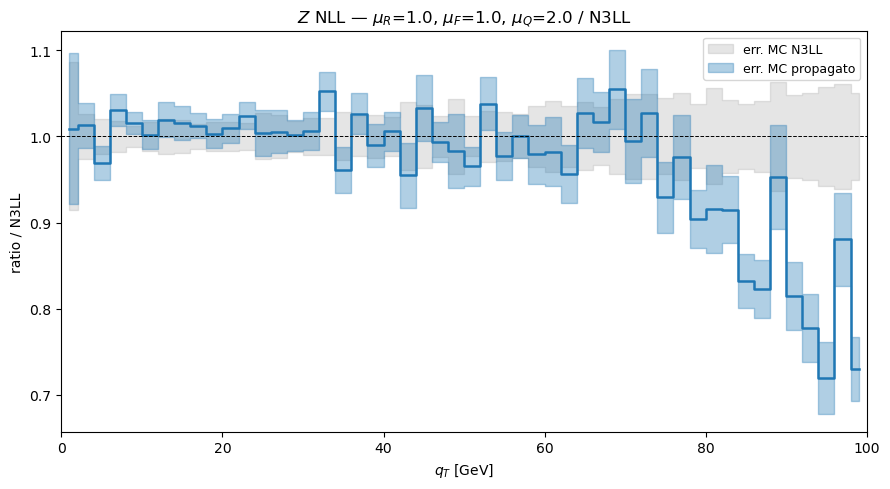

NLL  muR=1.0  muF=2.0  muQ=1.0 | ratio[0]=1.0146  ratio[-1]=0.7589  nrows=50


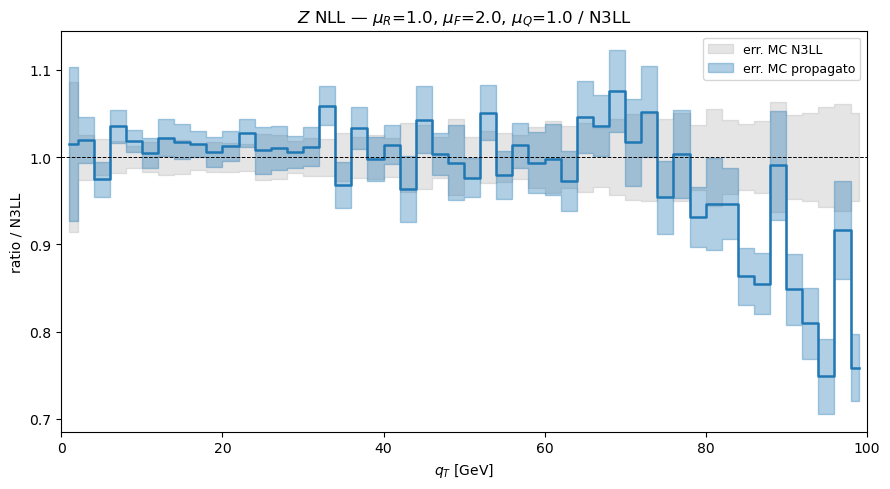

NLL  muR=1.0  muF=2.0  muQ=2.0 | ratio[0]=1.0146  ratio[-1]=0.7589  nrows=50


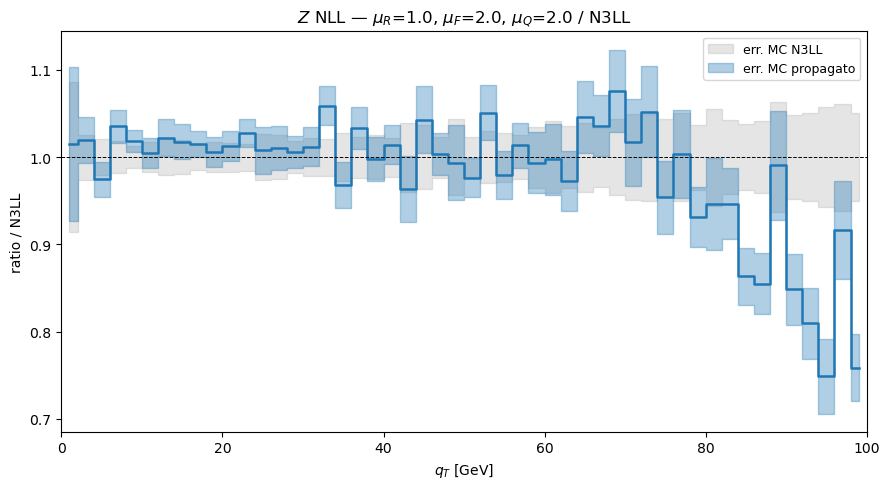

NLL  muR=2.0  muF=1.0  muQ=1.0 | ratio[0]=1.0314  ratio[-1]=0.7001  nrows=50


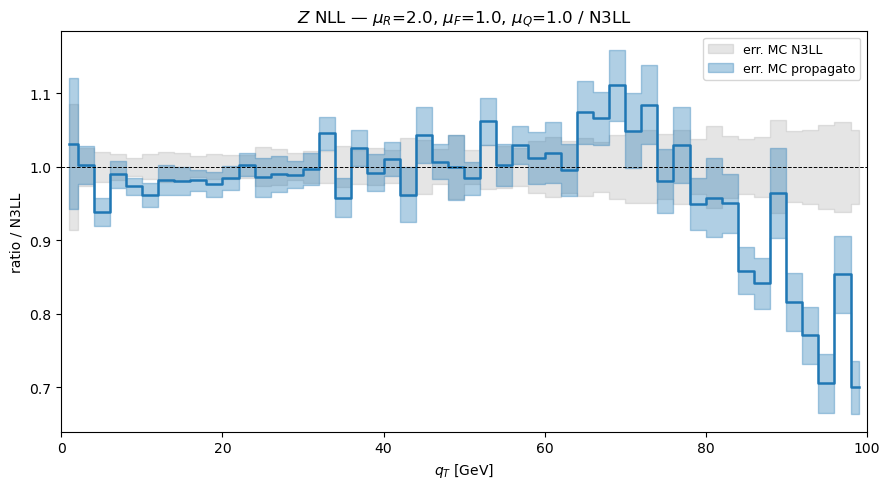

NLL  muR=2.0  muF=1.0  muQ=2.0 | ratio[0]=1.0314  ratio[-1]=0.7001  nrows=50


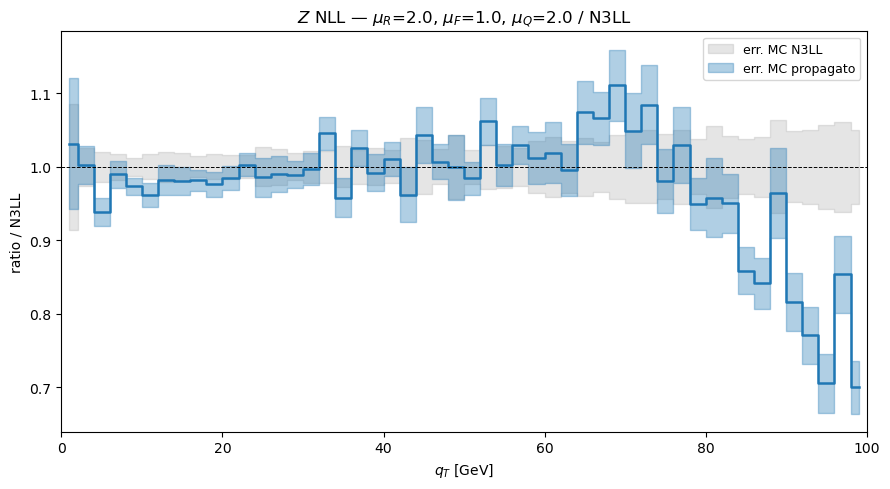

NLL  muR=2.0  muF=2.0  muQ=1.0 | ratio[0]=1.0147  ratio[-1]=0.7280  nrows=50


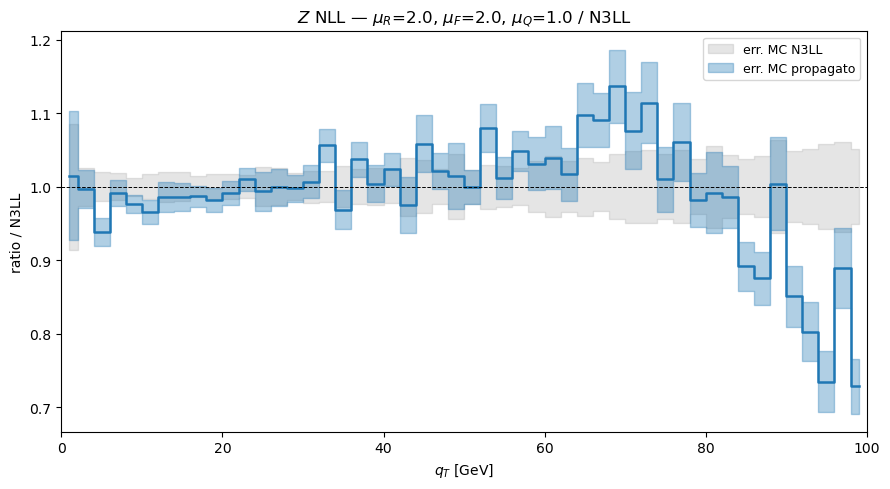

NLL  muR=2.0  muF=2.0  muQ=2.0 | ratio[0]=1.0147  ratio[-1]=0.7280  nrows=50


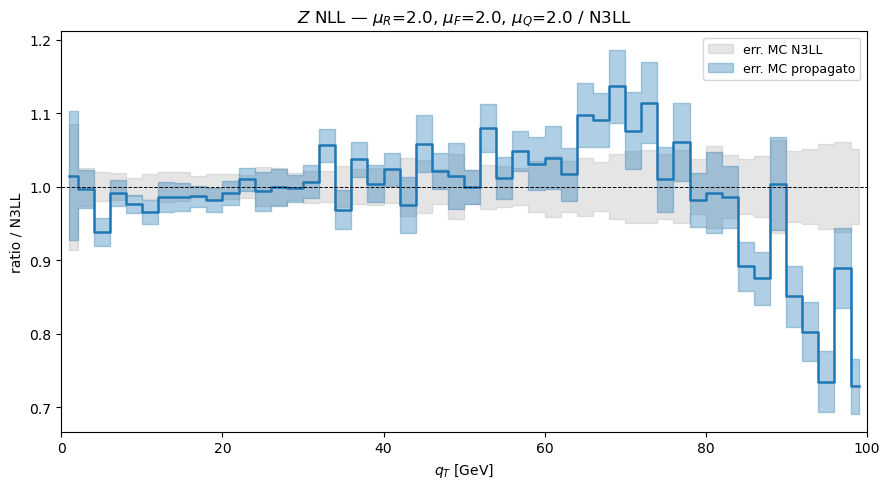

NNLL  muR=0.5  muF=0.5  muQ=0.5 | ratio[0]=1.1073  ratio[-1]=1.0287  nrows=50


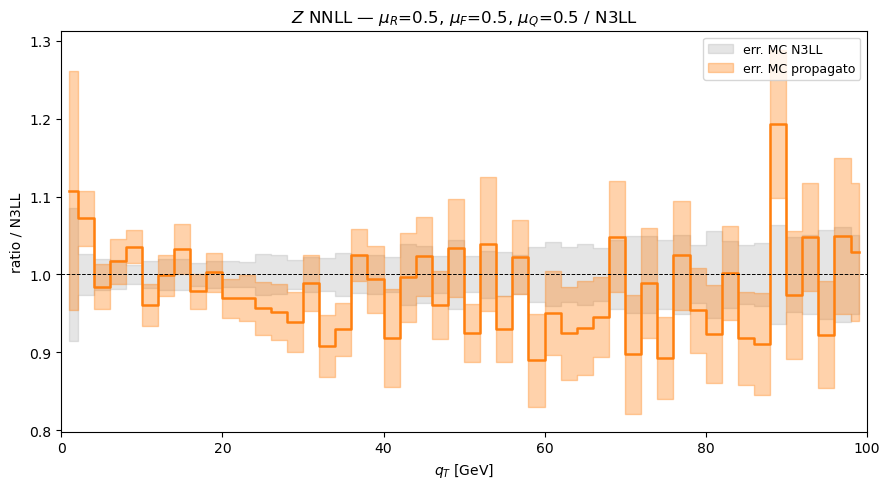

NNLL  muR=0.5  muF=0.5  muQ=1.0 | ratio[0]=1.1069  ratio[-1]=1.0287  nrows=50


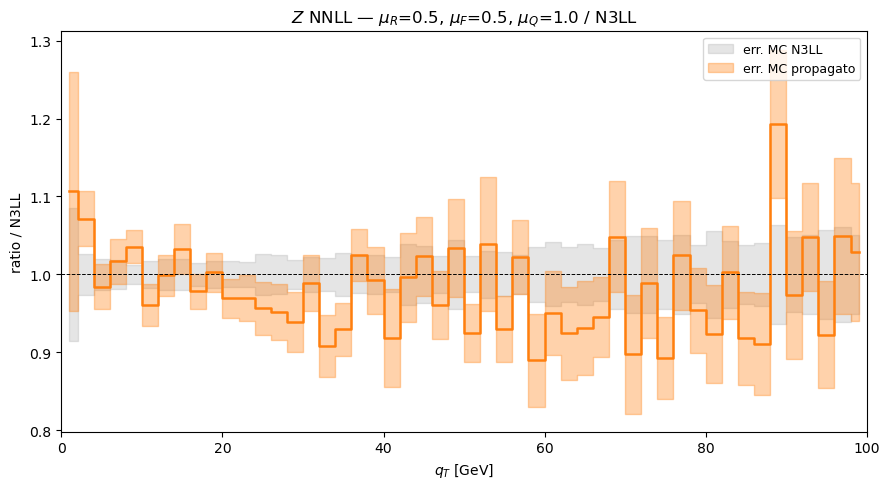

NNLL  muR=0.5  muF=1.0  muQ=0.5 | ratio[0]=0.9955  ratio[-1]=0.9823  nrows=50


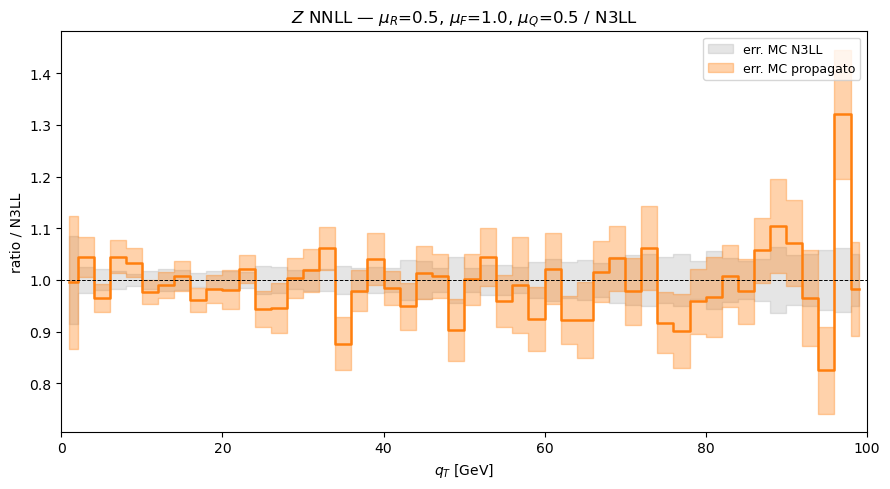

NNLL  muR=0.5  muF=1.0  muQ=1.0 | ratio[0]=0.9951  ratio[-1]=0.9823  nrows=50


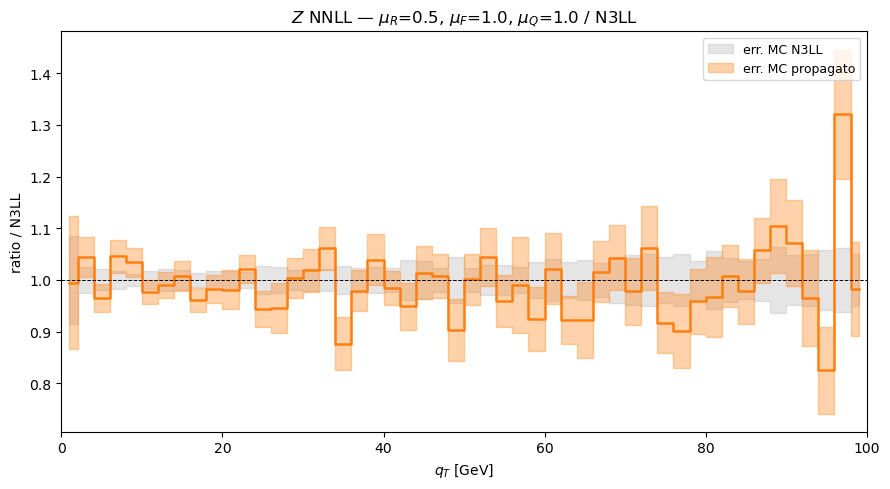

NNLL  muR=1.0  muF=0.5  muQ=0.5 | ratio[0]=0.9388  ratio[-1]=1.0314  nrows=50


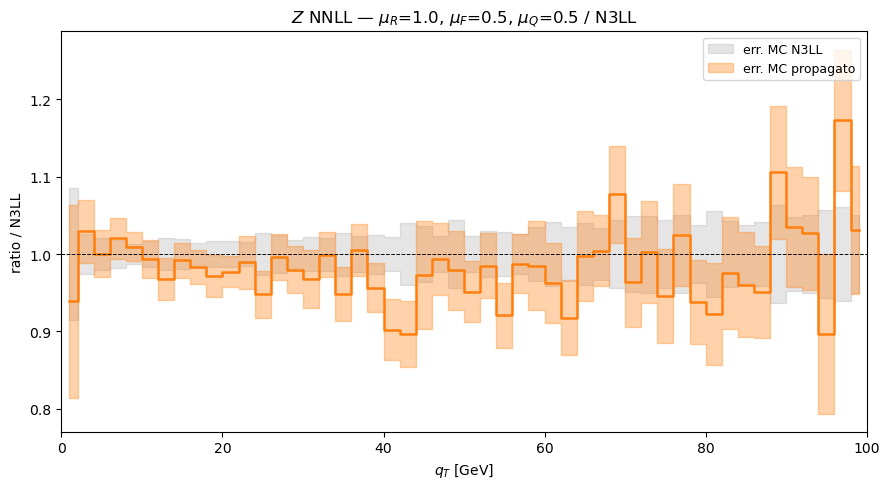

NNLL  muR=1.0  muF=0.5  muQ=1.0 | ratio[0]=0.9387  ratio[-1]=1.0313  nrows=50


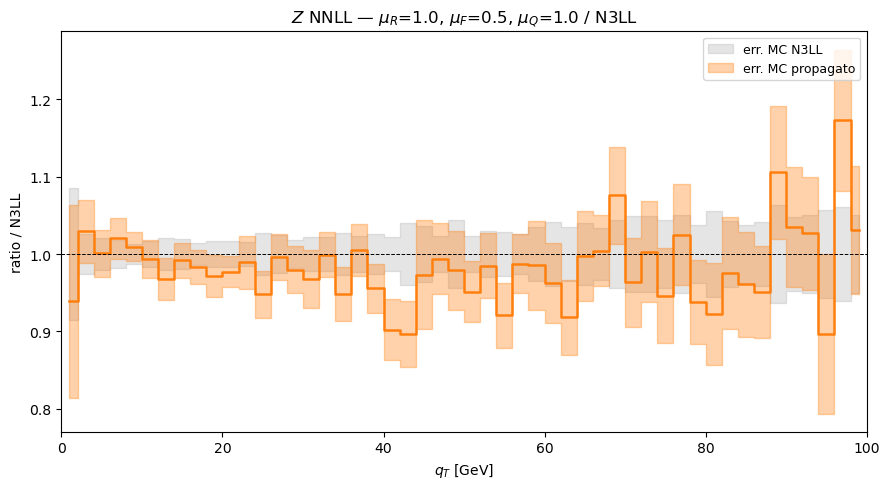

NNLL  muR=1.0  muF=1.0  muQ=0.5 | ratio[0]=1.1356  ratio[-1]=1.0145  nrows=50


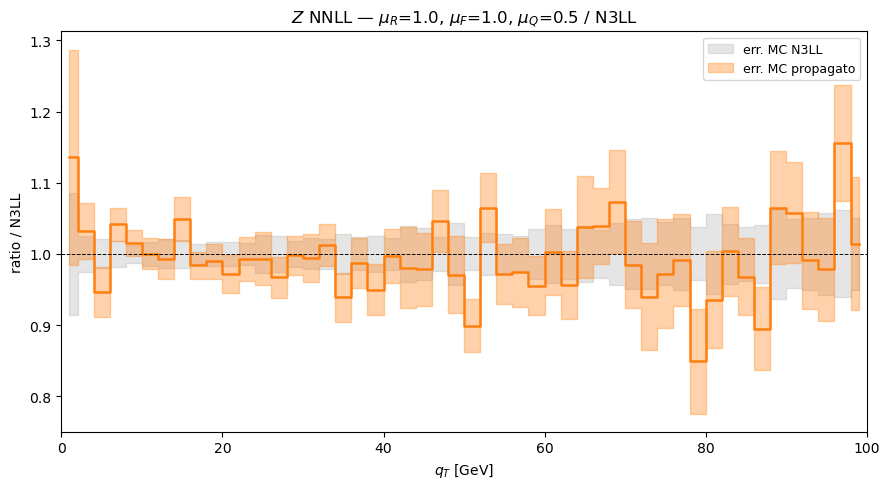

NNLL  muR=1.0  muF=1.0  muQ=1.0 | ratio[0]=1.1355  ratio[-1]=1.0145  nrows=50


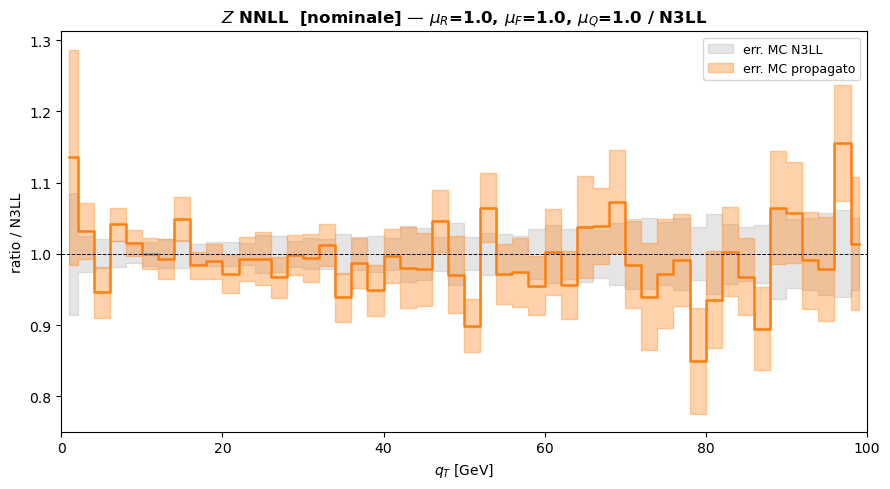

NNLL  muR=1.0  muF=1.0  muQ=2.0 | ratio[0]=1.1355  ratio[-1]=1.0145  nrows=50


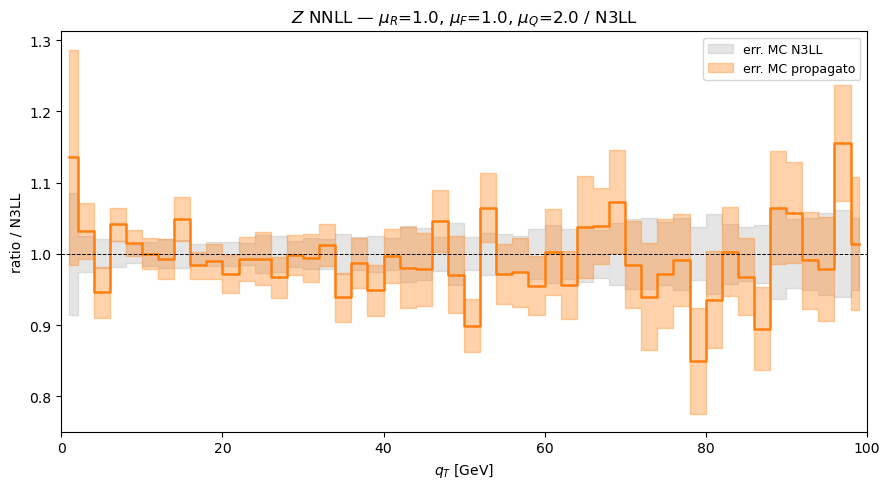

NNLL  muR=1.0  muF=2.0  muQ=1.0 | ratio[0]=0.9419  ratio[-1]=0.9918  nrows=50


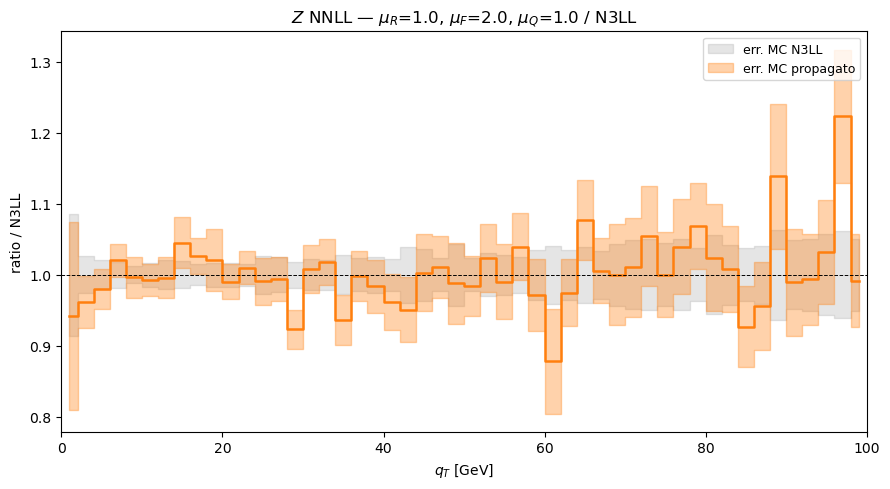

NNLL  muR=1.0  muF=2.0  muQ=2.0 | ratio[0]=0.9419  ratio[-1]=0.9918  nrows=50


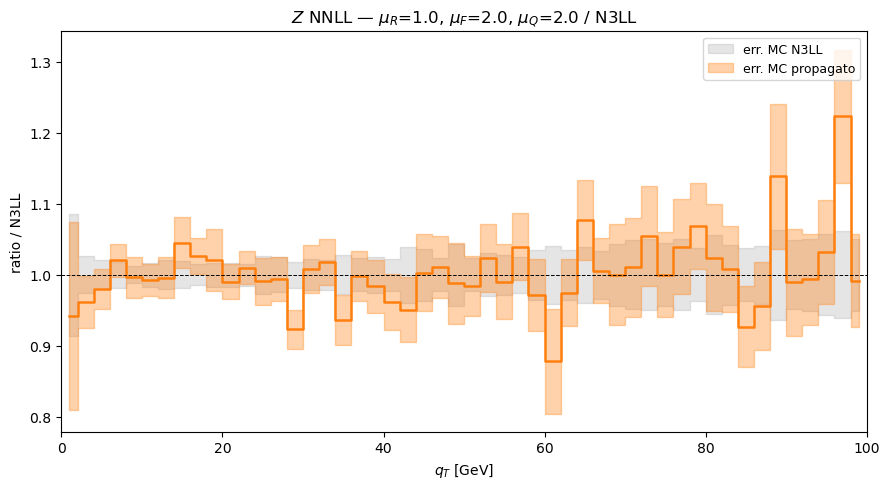

NNLL  muR=2.0  muF=1.0  muQ=1.0 | ratio[0]=0.8984  ratio[-1]=0.9422  nrows=50


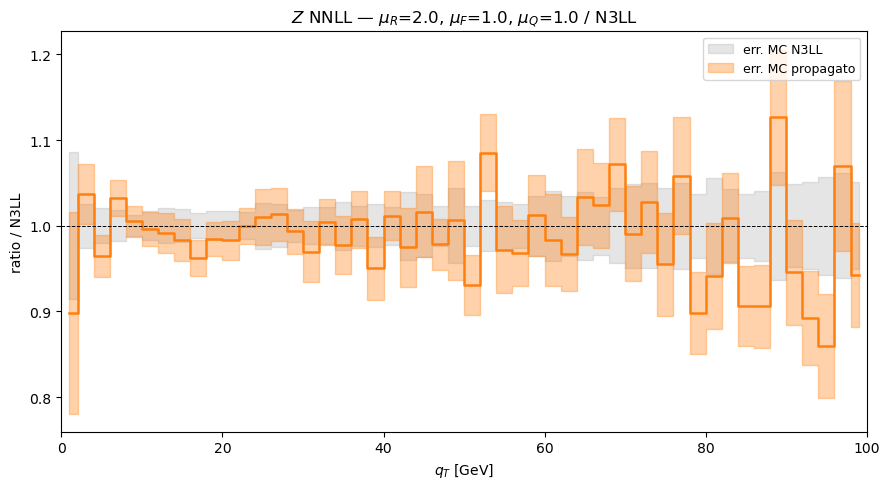

NNLL  muR=2.0  muF=1.0  muQ=2.0 | ratio[0]=0.8984  ratio[-1]=0.9422  nrows=50


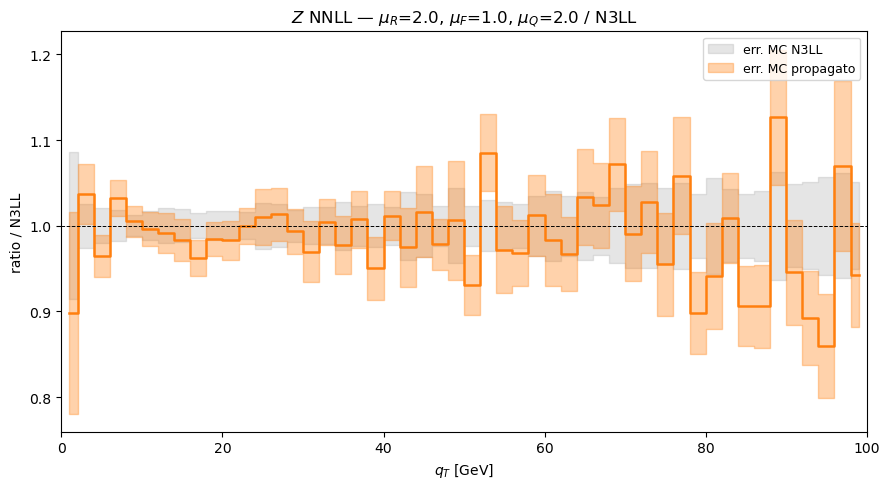

NNLL  muR=2.0  muF=2.0  muQ=1.0 | ratio[0]=0.9608  ratio[-1]=0.9015  nrows=50


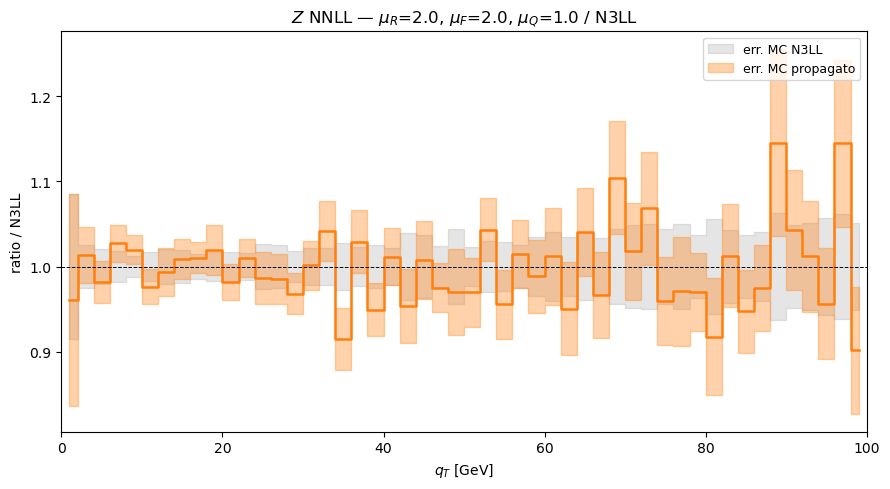

NNLL  muR=2.0  muF=2.0  muQ=2.0 | ratio[0]=0.9608  ratio[-1]=0.9015  nrows=50


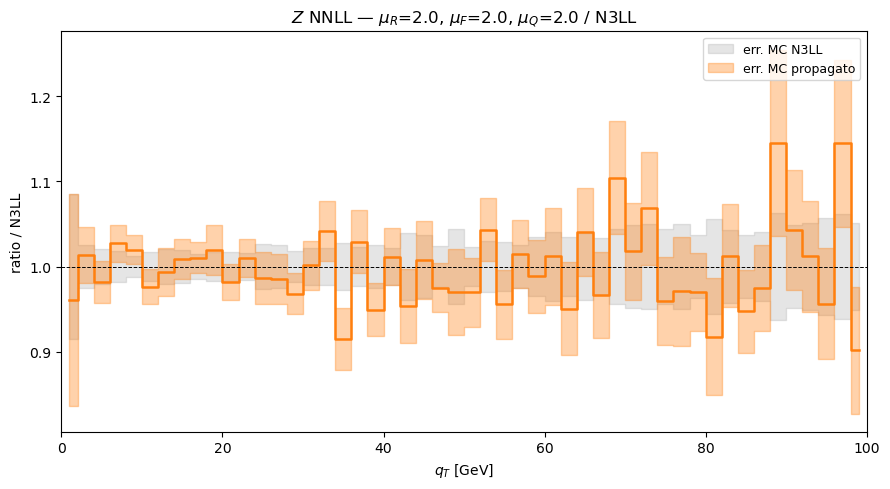

In [158]:
BOSON = 'Z'

# ── pseudo-dati N3LL (riferimento fisso) ──────────────────────────────────────
ref = (df1d[(df1d.boson == BOSON) & (df1d.order == 'N3LL') &
            (df1d.muR == 1.0) & (df1d.muF == 1.0) & (df1d.muQ == 1.0)]
       .copy().set_index('qt_lo').sort_index())

for ORDER, color in [('NLL', 'C0'), ('NNLL', 'C1')]:
    sub = df1d[(df1d.boson == BOSON) & (df1d.order == ORDER)].copy()
    scales_df = (sub.groupby(['muR','muF','muQ'])
                    .size().reset_index()[['muR','muF','muQ']])

    for _, sc in scales_df.iterrows():
        mur, muf, muq = sc['muR'], sc['muF'], sc['muQ']

        grp = (sub[(sub.muR == mur) & (sub.muF == muf) & (sub.muQ == muq)]
               .copy().set_index('qt_lo').sort_index())

        common = sorted(set(grp.index) & set(ref.index))
        if not common:
            continue

        qt_c  = grp.loc[common, 'qt_center'].values
        v_i   = grp.loc[common, 'value'].values
        e_i   = grp.loc[common, 'error'].values
        v_r   = ref.loc[common, 'value'].values
        e_r   = ref.loc[common, 'error'].values

        ratio     = v_i / v_r
        ratio_err = ratio * np.sqrt((e_i / v_i)**2 + (e_r / v_r)**2)

        is_nom = (mur == 1.0 and muf == 1.0 and muq == 1.0)

        # ── verifica ─────────────────────────────────────────────────────────
        print(f"{ORDER}  muR={mur}  muF={muf}  muQ={muq} "
              f"| ratio[0]={ratio[0]:.4f}  ratio[-1]={ratio[-1]:.4f}  "
              f"nrows={len(grp)}")

        fig, ax = plt.subplots(figsize=(9, 5))

        # banda grigia: errore relativo N3LL (denominatore)
        ax.fill_between(qt_c, 1 - e_r/v_r, 1 + e_r/v_r,
                        step='mid', alpha=0.20, color='gray',
                        label='err. MC N3LL')

        # ratio con banda di errore propagato
        ax.step(qt_c, ratio, where='mid', color=color, linewidth=1.8)
        ax.fill_between(qt_c, ratio - ratio_err, ratio + ratio_err,
                        step='mid', alpha=0.35, color=color,
                        label='err. MC propagato')

        ax.axhline(1, color='k', linewidth=0.7, linestyle='--')

        nom_tag = '  [nominale]' if is_nom else ''
        ax.set_title(
            f'$Z$ {ORDER}{nom_tag} — '
            f'$\\mu_R$={mur:.1f}, $\\mu_F$={muf:.1f}, $\\mu_Q$={muq:.1f} / N3LL',
            fontweight='bold' if is_nom else 'normal'
        )
        ax.set_xlabel(r'$q_T$ [GeV]')
        ax.set_ylabel('ratio / N3LL')
        ax.set_xlim(0, 100)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
